# Library

In [1]:
import pandas as pd

# Data

In [6]:
data = pd.read_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/final_data_ready_modelling.csv')
data.head(3)

,Harga_Asli,kecamatan,bedroom,bathrooms,jumlah_guest_toilet,lantai,area_digunakan,luas_tanah,latitude,longitude,...,Rumah jaga,Spa dan Sauna,Taman,Taman atap,Taman bermain anak,Tidak Ada,akses_transportasi,akses_pendidikan,akses_komersial,fasilitas_premium
0,385000000,Wonoayu,2,1,1,1,34,10,-7.437160,112.622220,...,1,0,1,0,0,0,5.362372,5.405134,8.244602,0
1,540000000,Sedati,2,1,1,1,32,32,-7.395451,112.769745,...,1,0,1,0,0,0,2.463128,1.168335,5.299212,0
2,1960000000,Candi,4,3,3,3,72,32,-7.458483,112.700560,...,1,0,1,0,0,0,1.945620,0.674588,1.426830,0


In [10]:
X = data.drop(columns=["Harga_Asli","latitude","longitude"])

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 72 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   kecamatan                          1231 non-null   object 
 1   bedroom                            1231 non-null   int64  
 2   bathrooms                          1231 non-null   int64  
 3   jumlah_guest_toilet                1231 non-null   int64  
 4   lantai                             1231 non-null   int64  
 5   area_digunakan                     1231 non-null   int64  
 6   luas_tanah                         1231 non-null   int64  
 7   dist_SD                            1231 non-null   float64
 8   dist_Universitas                   1231 non-null   float64
 9   dist_Fasilitas_Kesehatan           1231 non-null   float64
 10  dist_Minimarket                    1231 non-null   float64
 11  dist_Bandara                       1231 non-null   float

In [13]:
# Melihat kolom berdasarkan tipe data
print("Kolom Numerik Kontinu:")
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(numeric_cols)
print(f"\nJumlah: {len(numeric_cols)}")

print("\n" + "="*50)
print("\nKolom Kategorikal:")
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)
print(f"\nJumlah: {len(categorical_cols)}")

Kolom Numerik Kontinu:
['bedroom', 'bathrooms', 'jumlah_guest_toilet', 'lantai', 'area_digunakan', 'luas_tanah', 'dist_SD', 'dist_Universitas', 'dist_Fasilitas_Kesehatan', 'dist_Minimarket', 'dist_Bandara', 'dist_Entry_Exit_Tol', 'road_score', 'has_exit_tol', 'AC', 'Air', 'Alarm', 'Balkon', 'Berperabot lengkap', 'Dapur lengkap', 'Dapur terpadu', 'Deck', 'Fully fenced', 'Garasi', 'Gas alam', 'Halaman', 'Halaman terbuka', 'Internet', 'Jaringan internet', 'Kabel video', 'Kitchen set', 'Lemari pakaian bawaan', 'Listrik', 'Pagar penuh', 'Pemanas ruangan', 'Pemanasan', 'Pemandangan panorama', 'Pendingin ruangan (AC)', 'Perapian', 'Ruang kantor', 'Ruang layanan', 'Rubanah', 'Sebagian perabotan', 'Setengah terpisah', 'Sistem Alarm', 'TV kabel', 'Tangki air', 'Tanpa perabotan', 'Teras', 'Wifi', 'Akses bagi penyandang disabilitas', 'Area anak-anak', 'BBQ Area', 'Cctv', 'Gym', 'Keamanan', 'Keamanan 24 jam', 'Kolam renang', 'Lapangan tenis', 'Panggang', 'Pramutamu', 'Rumah jaga', 'Spa dan Sauna', 

# ANOVA

In [14]:
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Definisikan target variable - menggunakan harga asli
y = data['Harga_Asli']

# Buat kategori harga untuk analisis (misal: rendah, menengah, tinggi)
# Menggunakan quartiles untuk membagi kategori
y_quantiles = pd.qcut(y, q=4, labels=['Rendah', 'Menengah-Rendah', 'Menengah-Tinggi', 'Tinggi'])
print("Distribusi Kategori Harga:")
print(y_quantiles.value_counts())

# Identifikasi tipe variabel
# Variabel biner (0/1) - untuk Chi-Square
binary_cols = [col for col in X.columns if X[col].nunique() == 2 and set(X[col].unique()).issubset({0, 1})]

# Variabel numerik kontinu - untuk ANOVA  
continuous_cols = [col for col in X.columns if col not in binary_cols and X[col].dtype in ['int64', 'float64']]

# Variabel kategorikal nominal
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n{'='*60}")
print(f"Variabel Biner (untuk Chi-Square): {len(binary_cols)}")
print(f"Variabel Kontinu (untuk ANOVA): {len(continuous_cols)}")
print(f"Variabel Kategorikal Nominal (untuk Chi-Square): {len(categorical_cols)}")

Distribusi Kategori Harga:
Harga_Asli
Rendah             321
Menengah-Rendah    310
Tinggi             305
Menengah-Tinggi    295
Name: count, dtype: int64

Variabel Biner (untuk Chi-Square): 54
Variabel Kontinu (untuk ANOVA): 17
Variabel Kategorikal Nominal (untuk Chi-Square): 1


In [15]:
# ============================================================
# ANOVA TEST untuk Variabel Numerik Kontinu
# ============================================================
# ANOVA menguji apakah ada perbedaan signifikan rata-rata variabel
# antar kelompok kategori harga

def perform_anova(X, y_cat, continuous_cols, alpha=0.05):
    """
    Melakukan ANOVA test untuk variabel kontinu
    H0: Tidak ada perbedaan rata-rata antar kelompok
    H1: Ada perbedaan rata-rata antar kelompok (minimal satu)
    """
    anova_results = []
    
    for col in continuous_cols:
        # Kelompokkan data berdasarkan kategori harga
        groups = [X[col][y_cat == cat].dropna() for cat in y_cat.unique()]
        
        # Pastikan semua grup memiliki data
        groups = [g for g in groups if len(g) > 0]
        
        if len(groups) >= 2:
            # Lakukan ANOVA
            f_stat, p_value = f_oneway(*groups)
            
            # Hitung Effect Size (Eta-squared)
            # Eta² = SS_between / SS_total
            grand_mean = X[col].mean()
            ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
            ss_total = sum((X[col] - grand_mean)**2)
            eta_squared = ss_between / ss_total if ss_total != 0 else 0
            
            # Interpretasi effect size
            if eta_squared < 0.01:
                effect_interp = "Negligible"
            elif eta_squared < 0.06:
                effect_interp = "Small"
            elif eta_squared < 0.14:
                effect_interp = "Medium"
            else:
                effect_interp = "Large"
            
            anova_results.append({
                'Variabel': col,
                'F-Statistic': round(f_stat, 4),
                'P-Value': p_value,
                'Eta-Squared': round(eta_squared, 4),
                'Effect Size': effect_interp,
                'Signifikan': 'Ya' if p_value < alpha else 'Tidak',
                'Relevan': 'Ya' if (p_value < alpha and eta_squared >= 0.01) else 'Tidak'
            })
    
    return pd.DataFrame(anova_results)

# Jalankan ANOVA
anova_df = perform_anova(X, y_quantiles, continuous_cols)
anova_df = anova_df.sort_values('P-Value')

print("="*80)
print("HASIL ANALISIS ANOVA - VARIABEL NUMERIK KONTINU")
print("="*80)
print(f"\nH0: Tidak ada perbedaan rata-rata variabel antar kategori harga")
print(f"H1: Ada perbedaan rata-rata variabel antar kategori harga")
print(f"Alpha (α): 0.05")
print(f"\nInterpretasi Effect Size (Eta-Squared):")
print("  - Negligible: η² < 0.01")
print("  - Small: 0.01 ≤ η² < 0.06")
print("  - Medium: 0.06 ≤ η² < 0.14")
print("  - Large: η² ≥ 0.14")
print("\n")

# Format P-Value untuk display
anova_display = anova_df.copy()
anova_display['P-Value'] = anova_display['P-Value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')
print(anova_display.to_string(index=False))

print(f"\n\nRingkasan ANOVA:")
print(f"  - Total Variabel: {len(continuous_cols)}")
print(f"  - Variabel Signifikan (p < 0.05): {len(anova_df[anova_df['Signifikan'] == 'Ya'])}")
print(f"  - Variabel Relevan (signifikan + effect size ≥ small): {len(anova_df[anova_df['Relevan'] == 'Ya'])}")

HASIL ANALISIS ANOVA - VARIABEL NUMERIK KONTINU

H0: Tidak ada perbedaan rata-rata variabel antar kategori harga
H1: Ada perbedaan rata-rata variabel antar kategori harga
Alpha (α): 0.05

Interpretasi Effect Size (Eta-Squared):
  - Negligible: η² < 0.01
  - Small: 0.01 ≤ η² < 0.06
  - Medium: 0.06 ≤ η² < 0.14
  - Large: η² ≥ 0.14


                Variabel  F-Statistic  P-Value  Eta-Squared Effect Size Signifikan Relevan
               bathrooms     138.7454 2.11e-77       0.2533       Large         Ya      Ya
                 bedroom     101.0932 1.76e-58       0.1982       Large         Ya      Ya
         akses_komersial      37.3427 4.29e-23       0.0837      Medium         Ya      Ya
            dist_Bandara      30.5669 4.66e-19       0.0695      Medium         Ya      Ya
        dist_Universitas      24.6209 1.80e-15       0.0568       Small         Ya      Ya
              road_score      18.0923 1.72e-11       0.0424       Small         Ya      Ya
dist_Fasilitas_Kesehatan     

# Chi-Square

In [16]:
# ============================================================
# CHI-SQUARE TEST untuk Variabel Kategorikal & Biner
# ============================================================
# Chi-Square menguji independensi antara variabel kategorikal dengan kategori harga

def perform_chi_square(X, y_cat, cols, alpha=0.05):
    """
    Melakukan Chi-Square test untuk variabel kategorikal/biner
    H0: Variabel independen terhadap kategori harga (tidak ada hubungan)
    H1: Variabel dependen terhadap kategori harga (ada hubungan)
    """
    chi2_results = []
    
    for col in cols:
        try:
            # Buat contingency table
            contingency_table = pd.crosstab(X[col], y_cat)
            
            # Lakukan Chi-Square test
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            
            # Hitung Cramér's V (effect size untuk chi-square)
            n = contingency_table.sum().sum()
            min_dim = min(contingency_table.shape) - 1
            cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
            
            # Interpretasi effect size (Cramér's V)
            if cramers_v < 0.1:
                effect_interp = "Negligible"
            elif cramers_v < 0.3:
                effect_interp = "Small"
            elif cramers_v < 0.5:
                effect_interp = "Medium"
            else:
                effect_interp = "Large"
            
            chi2_results.append({
                'Variabel': col,
                'Chi-Square': round(chi2, 4),
                'P-Value': p_value,
                'DoF': dof,
                "Cramér's V": round(cramers_v, 4),
                'Effect Size': effect_interp,
                'Signifikan': 'Ya' if p_value < alpha else 'Tidak',
                'Relevan': 'Ya' if (p_value < alpha and cramers_v >= 0.1) else 'Tidak'
            })
        except Exception as e:
            print(f"Error pada variabel {col}: {e}")
    
    return pd.DataFrame(chi2_results)

# Gabungkan variabel biner dan kategorikal
chi_square_cols = binary_cols + categorical_cols

# Jalankan Chi-Square
chi2_df = perform_chi_square(X, y_quantiles, chi_square_cols)
chi2_df = chi2_df.sort_values('P-Value')

print("="*80)
print("HASIL ANALISIS CHI-SQUARE - VARIABEL KATEGORIKAL & BINER")
print("="*80)
print(f"\nH0: Variabel independen terhadap kategori harga (tidak ada hubungan)")
print(f"H1: Variabel dependen terhadap kategori harga (ada hubungan)")
print(f"Alpha (α): 0.05")
print(f"\nInterpretasi Effect Size (Cramér's V):")
print("  - Negligible: V < 0.1")
print("  - Small: 0.1 ≤ V < 0.3")
print("  - Medium: 0.3 ≤ V < 0.5")
print("  - Large: V ≥ 0.5")
print("\n")

# Format P-Value untuk display
chi2_display = chi2_df.copy()
chi2_display['P-Value'] = chi2_display['P-Value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')
print(chi2_display.to_string(index=False))

print(f"\n\nRingkasan Chi-Square:")
print(f"  - Total Variabel: {len(chi_square_cols)}")
print(f"  - Variabel Signifikan (p < 0.05): {len(chi2_df[chi2_df['Signifikan'] == 'Ya'])}")
print(f"  - Variabel Relevan (signifikan + effect size ≥ small): {len(chi2_df[chi2_df['Relevan'] == 'Ya'])}")

HASIL ANALISIS CHI-SQUARE - VARIABEL KATEGORIKAL & BINER

H0: Variabel independen terhadap kategori harga (tidak ada hubungan)
H1: Variabel dependen terhadap kategori harga (ada hubungan)
Alpha (α): 0.05

Interpretasi Effect Size (Cramér's V):
  - Negligible: V < 0.1
  - Small: 0.1 ≤ V < 0.3
  - Medium: 0.3 ≤ V < 0.5
  - Large: V ≥ 0.5


                         Variabel  Chi-Square  P-Value  DoF  Cramér's V Effect Size Signifikan Relevan
                        kecamatan    422.0378 7.33e-60   51      0.3381      Medium         Ya      Ya
                   Area anak-anak     73.0567 9.45e-16    3      0.2436       Small         Ya      Ya
                            Taman     38.8908 1.83e-08    3      0.1777       Small         Ya      Ya
                  Tanpa perabotan     36.3184 6.41e-08    3      0.1718       Small         Ya      Ya
                     has_exit_tol     32.1089 4.96e-07    3      0.1615       Small         Ya      Ya
                       Rumah jaga     29.8

# Results

In [18]:
# ============================================================
# HASIL AKHIR: KOMBINASI ANOVA & CHI-SQUARE
# ============================================================

print("="*100)
print("RINGKASAN HASIL ANALISIS FEATURE SELECTION (ANOVA & CHI-SQUARE)")
print("="*100)

# Variabel relevan dari ANOVA
anova_relevant = anova_df[anova_df['Relevan'] == 'Ya']['Variabel'].tolist()

# Variabel relevan dari Chi-Square
chi2_relevant = chi2_df[chi2_df['Relevan'] == 'Ya']['Variabel'].tolist()

# Gabungkan semua variabel relevan
all_relevant = anova_relevant + chi2_relevant

print(f"\n{'='*50}")
print("VARIABEL RELEVAN DARI ANOVA (Numerik Kontinu)")
print(f"{'='*50}")
print(f"Total: {len(anova_relevant)} variabel\n")
for i, var in enumerate(anova_relevant, 1):
    row = anova_df[anova_df['Variabel'] == var].iloc[0]
    print(f"  {i:2d}. {var:<30} | F={row['F-Statistic']:>10.2f} | eta2={row['Eta-Squared']:.4f} | {row['Effect Size']}")

print(f"\n{'='*50}")
print("VARIABEL RELEVAN DARI CHI-SQUARE (Kategorikal/Biner)")
print(f"{'='*50}")
print(f"Total: {len(chi2_relevant)} variabel\n")
for i, var in enumerate(chi2_relevant, 1):
    row = chi2_df[chi2_df['Variabel'] == var].iloc[0]
    cramers = row["Cramér's V"]
    print(f"  {i:2d}. {var:<30} | chi2={row['Chi-Square']:>10.2f} | V={cramers:.4f} | {row['Effect Size']}")

# Buat DataFrame hasil akhir
print(f"\n\n{'='*100}")
print("TABEL RINGKASAN VARIABEL RELEVAN")
print("="*100)

# ANOVA results
anova_summary = anova_df[anova_df['Relevan'] == 'Ya'][['Variabel', 'F-Statistic', 'P-Value', 'Eta-Squared', 'Effect Size']].copy()
anova_summary['Metode'] = 'ANOVA'
anova_summary['Statistic'] = anova_summary['F-Statistic']
anova_summary['Effect Metric'] = anova_summary['Eta-Squared']
anova_summary = anova_summary[['Variabel', 'Metode', 'Statistic', 'P-Value', 'Effect Metric', 'Effect Size']]

# Chi-Square results
chi2_summary = chi2_df[chi2_df['Relevan'] == 'Ya'][['Variabel', 'Chi-Square', 'P-Value', "Cramér's V", 'Effect Size']].copy()
chi2_summary['Metode'] = 'Chi-Square'
chi2_summary['Statistic'] = chi2_summary['Chi-Square']
chi2_summary['Effect Metric'] = chi2_summary["Cramér's V"]
chi2_summary = chi2_summary[['Variabel', 'Metode', 'Statistic', 'P-Value', 'Effect Metric', 'Effect Size']]

# Gabungkan
final_summary = pd.concat([anova_summary, chi2_summary], ignore_index=True)
final_summary['P-Value'] = final_summary['P-Value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')
final_summary['Statistic'] = final_summary['Statistic'].round(4)
final_summary['Effect Metric'] = final_summary['Effect Metric'].round(4)

print(final_summary.to_string(index=False))

# Kesimpulan
print(f"\n\n{'='*100}")
print("KESIMPULAN")
print("="*100)
total_vars = len(continuous_cols) + len(chi_square_cols)

conclusion = f"""
📊 ANALISIS FEATURE SELECTION BERHASIL DILAKUKAN

┌─────────────────────────────────────────────────────────────────────┐
│ RINGKASAN STATISTIK                                                 │
├─────────────────────────────────────────────────────────────────────┤
│ Total Variabel Dianalisis       : {total_vars:>3} variabel                     │
│   • Variabel Numerik (ANOVA)    : {len(continuous_cols):>3} variabel                     │
│   • Variabel Biner/Kat (χ²)     : {len(chi_square_cols):>3} variabel                     │
├─────────────────────────────────────────────────────────────────────┤
│ VARIABEL RELEVAN (p < 0.05 & effect size ≥ small)                  │
│   • Dari ANOVA                  : {len(anova_relevant):>3} variabel                     │
│   • Dari Chi-Square             : {len(chi2_relevant):>3} variabel                     │
│   • Total Variabel Relevan      : {len(all_relevant):>3} variabel                     │
├─────────────────────────────────────────────────────────────────────┤
│ REDUKSI DIMENSI                                                     │
│   • Variabel Tereliminasi       : {total_vars - len(all_relevant):>3} variabel                     │
│   • Persentase Reduksi          : {((total_vars - len(all_relevant))/total_vars)*100:>5.1f}%                          │
└─────────────────────────────────────────────────────────────────────┘

📝 INTERPRETASI:
   - Variabel RELEVAN adalah variabel yang memiliki hubungan signifikan 
     (p-value < 0.05) DAN memiliki effect size minimal 'Small'
   - ANOVA: Eta-squared (η²) ≥ 0.01 untuk efek minimal 'Small'
   - Chi-Square: Cramér's V ≥ 0.10 untuk efek minimal 'Small'
   
🎯 REKOMENDASI:
   - Gunakan {len(all_relevant)} variabel relevan untuk pemodelan selanjutnya
   - Variabel dengan effect size 'Large' atau 'Medium' sangat penting
"""
print(conclusion)

# List variabel relevan untuk digunakan nanti
print(f"\n{'='*100}")
print("DAFTAR VARIABEL RELEVAN UNTUK MODELLING")
print("="*100)
print(f"\nVariabel yang direkomendasikan untuk pemodelan ({len(all_relevant)} variabel):\n")
print(all_relevant)

RINGKASAN HASIL ANALISIS FEATURE SELECTION (ANOVA & CHI-SQUARE)

VARIABEL RELEVAN DARI ANOVA (Numerik Kontinu)
Total: 12 variabel

   1. bathrooms                      | F=    138.75 | eta2=0.2533 | Large
   2. bedroom                        | F=    101.09 | eta2=0.1982 | Large
   3. akses_komersial                | F=     37.34 | eta2=0.0837 | Medium
   4. dist_Bandara                   | F=     30.57 | eta2=0.0695 | Medium
   5. dist_Universitas               | F=     24.62 | eta2=0.0568 | Small
   6. road_score                     | F=     18.09 | eta2=0.0424 | Small
   7. dist_Fasilitas_Kesehatan       | F=     15.48 | eta2=0.0365 | Small
   8. akses_pendidikan               | F=      9.27 | eta2=0.0222 | Small
   9. dist_SD                        | F=      7.84 | eta2=0.0188 | Small
  10. area_digunakan                 | F=      6.16 | eta2=0.0148 | Small
  11. luas_tanah                     | F=      4.99 | eta2=0.0120 | Small
  12. akses_transportasi             | F=      4.84 |

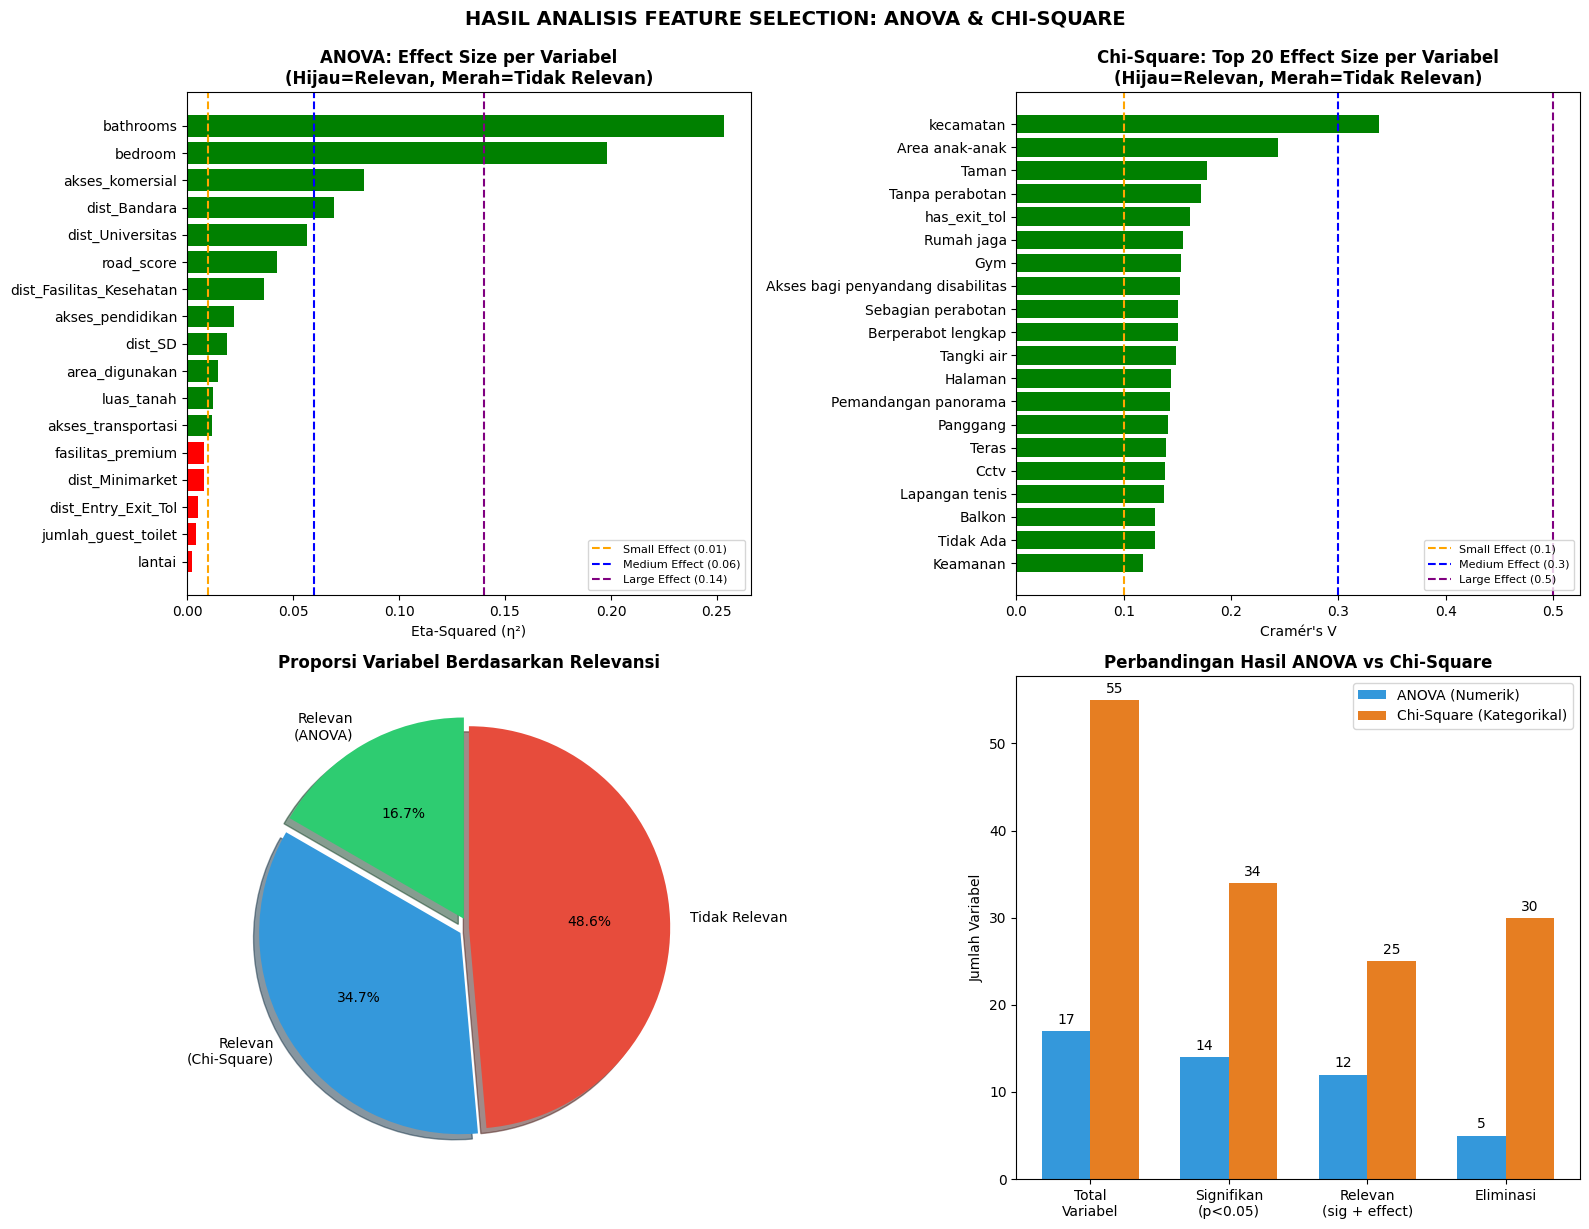


✅ Visualisasi disimpan di: /mnt/extended-home/ismaprasetiyadi/skripsi/data/feature_selection_results.png


In [19]:
# ============================================================
# VISUALISASI HASIL
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ANOVA - Effect Size Distribution
ax1 = axes[0, 0]
anova_colors = ['green' if x == 'Ya' else 'red' for x in anova_df['Relevan']]
bars1 = ax1.barh(anova_df['Variabel'], anova_df['Eta-Squared'], color=anova_colors)
ax1.axvline(x=0.01, color='orange', linestyle='--', label='Small Effect (0.01)')
ax1.axvline(x=0.06, color='blue', linestyle='--', label='Medium Effect (0.06)')
ax1.axvline(x=0.14, color='purple', linestyle='--', label='Large Effect (0.14)')
ax1.set_xlabel('Eta-Squared (η²)')
ax1.set_title('ANOVA: Effect Size per Variabel\n(Hijau=Relevan, Merah=Tidak Relevan)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.invert_yaxis()

# 2. Chi-Square - Top 20 Effect Size
ax2 = axes[0, 1]
chi2_top = chi2_df.nlargest(20, "Cramér's V")
chi2_colors = ['green' if x == 'Ya' else 'red' for x in chi2_top['Relevan']]
bars2 = ax2.barh(chi2_top['Variabel'], chi2_top["Cramér's V"], color=chi2_colors)
ax2.axvline(x=0.1, color='orange', linestyle='--', label='Small Effect (0.1)')
ax2.axvline(x=0.3, color='blue', linestyle='--', label='Medium Effect (0.3)')
ax2.axvline(x=0.5, color='purple', linestyle='--', label='Large Effect (0.5)')
ax2.set_xlabel("Cramér's V")
ax2.set_title("Chi-Square: Top 20 Effect Size per Variabel\n(Hijau=Relevan, Merah=Tidak Relevan)", fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.invert_yaxis()

# 3. Pie chart - Proporsi Variabel Relevan
ax3 = axes[1, 0]
labels = ['Relevan\n(ANOVA)', 'Relevan\n(Chi-Square)', 'Tidak Relevan']
sizes = [len(anova_relevant), len(chi2_relevant), total_vars - len(all_relevant)]
colors = ['#2ecc71', '#3498db', '#e74c3c']
explode = (0.05, 0.05, 0)
ax3.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax3.set_title('Proporsi Variabel Berdasarkan Relevansi', fontsize=12, fontweight='bold')

# 4. Bar chart - Summary
ax4 = axes[1, 1]
categories = ['Total\nVariabel', 'Signifikan\n(p<0.05)', 'Relevan\n(sig + effect)', 'Eliminasi']
anova_vals = [len(continuous_cols), len(anova_df[anova_df['Signifikan']=='Ya']), 
              len(anova_relevant), len(continuous_cols) - len(anova_relevant)]
chi2_vals = [len(chi_square_cols), len(chi2_df[chi2_df['Signifikan']=='Ya']), 
             len(chi2_relevant), len(chi_square_cols) - len(chi2_relevant)]

x = np.arange(len(categories))
width = 0.35
bars3 = ax4.bar(x - width/2, anova_vals, width, label='ANOVA (Numerik)', color='#3498db')
bars4 = ax4.bar(x + width/2, chi2_vals, width, label='Chi-Square (Kategorikal)', color='#e67e22')

ax4.set_ylabel('Jumlah Variabel')
ax4.set_title('Perbandingan Hasil ANOVA vs Chi-Square', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.legend()

# Tambahkan nilai di atas bar
for bar in bars3:
    height = bar.get_height()
    ax4.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars4:
    height = bar.get_height()
    ax4.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.suptitle('HASIL ANALISIS FEATURE SELECTION: ANOVA & CHI-SQUARE', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('/mnt/extended-home/ismaprasetiyadi/skripsi/data/feature_selection_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualisasi disimpan di: /mnt/extended-home/ismaprasetiyadi/skripsi/data/feature_selection_results.png")

In [20]:
# ============================================================
# EXPORT HASIL KE CSV
# ============================================================

# Simpan hasil ANOVA
anova_df.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/anova_results.csv', index=False)
print("✅ Hasil ANOVA disimpan: anova_results.csv")

# Simpan hasil Chi-Square
chi2_df.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/chi_square_results.csv', index=False)
print("✅ Hasil Chi-Square disimpan: chi_square_results.csv")

# Simpan daftar variabel relevan
relevant_vars_df = pd.DataFrame({
    'Variabel': all_relevant,
    'Metode': ['ANOVA'] * len(anova_relevant) + ['Chi-Square'] * len(chi2_relevant)
})
relevant_vars_df.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/relevant_variables.csv', index=False)
print("✅ Daftar variabel relevan disimpan: relevant_variables.csv")

# Buat dataset baru hanya dengan variabel relevan
X_selected = X[all_relevant]
print(f"\n📊 Dataset dengan variabel relevan:")
print(f"   Shape: {X_selected.shape}")
print(f"   Kolom: {list(X_selected.columns)}")

✅ Hasil ANOVA disimpan: anova_results.csv
✅ Hasil Chi-Square disimpan: chi_square_results.csv
✅ Daftar variabel relevan disimpan: relevant_variables.csv

📊 Dataset dengan variabel relevan:
   Shape: (1231, 37)
   Kolom: ['bathrooms', 'bedroom', 'akses_komersial', 'dist_Bandara', 'dist_Universitas', 'road_score', 'dist_Fasilitas_Kesehatan', 'akses_pendidikan', 'dist_SD', 'area_digunakan', 'luas_tanah', 'akses_transportasi', 'kecamatan', 'Area anak-anak', 'Taman', 'Tanpa perabotan', 'has_exit_tol', 'Rumah jaga', 'Gym', 'Akses bagi penyandang disabilitas', 'Sebagian perabotan', 'Berperabot lengkap', 'Tangki air', 'Halaman', 'Pemandangan panorama', 'Panggang', 'Teras', 'Cctv', 'Lapangan tenis', 'Balkon', 'Tidak Ada', 'Keamanan', 'Ruang kantor', 'Wifi', 'Fully fenced', 'Rubanah', 'Air']


# Analisis Hubungan Antar Variabel Prediktor (X)
## ANOVA: Numerik vs Biner | Chi-Square: Biner vs Biner

In [21]:
# ============================================================
# ANALISIS HUBUNGAN ANTAR VARIABEL PREDIKTOR
# ============================================================
# Tujuan: Menguji signifikansi hubungan antar variabel X (bukan X vs Y)
# 
# 1. ANOVA: Menguji apakah rata-rata variabel NUMERIK berbeda 
#           berdasarkan kategori variabel BINER
#           Contoh: Apakah rata-rata jumlah kamar berbeda antara 
#                   rumah dengan WiFi vs tanpa WiFi?
#
# 2. Chi-Square: Menguji independensi antara dua variabel BINER
#                Contoh: Apakah ada hubungan antara ada/tidaknya WiFi 
#                        dengan ada/tidaknya Halaman?

import numpy as np
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Identifikasi ulang tipe variabel
# Variabel biner (0/1)
binary_cols = [col for col in X.columns if X[col].nunique() == 2 and set(X[col].unique()).issubset({0, 1})]

# Variabel numerik kontinu (non-biner)
continuous_cols = [col for col in X.columns if col not in binary_cols and X[col].dtype in ['int64', 'float64']]

# Variabel kategorikal nominal
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("="*70)
print("IDENTIFIKASI VARIABEL UNTUK ANALISIS ANTAR PREDIKTOR")
print("="*70)
print(f"\n📊 Variabel Numerik Kontinu (untuk ANOVA): {len(continuous_cols)}")
print(f"   {continuous_cols[:5]}... " if len(continuous_cols) > 5 else f"   {continuous_cols}")
print(f"\n📊 Variabel Biner 0/1 (untuk ANOVA & Chi-Square): {len(binary_cols)}")
print(f"   {binary_cols[:5]}..." if len(binary_cols) > 5 else f"   {binary_cols}")
print(f"\n📊 Variabel Kategorikal: {len(categorical_cols)}")
print(f"   {categorical_cols}")

IDENTIFIKASI VARIABEL UNTUK ANALISIS ANTAR PREDIKTOR

📊 Variabel Numerik Kontinu (untuk ANOVA): 17
   ['bedroom', 'bathrooms', 'jumlah_guest_toilet', 'lantai', 'area_digunakan']... 

📊 Variabel Biner 0/1 (untuk ANOVA & Chi-Square): 54
   ['has_exit_tol', 'AC', 'Air', 'Alarm', 'Balkon']...

📊 Variabel Kategorikal: 1
   ['kecamatan']


In [22]:
# ============================================================
# ANOVA: Variabel NUMERIK vs Variabel BINER
# ============================================================
# Menguji: Apakah rata-rata variabel numerik berbeda secara signifikan
#          berdasarkan ada/tidaknya suatu fitur biner?
#
# Contoh: Apakah rata-rata jumlah kamar (bedroom) berbeda antara
#         rumah yang memiliki WiFi vs tidak memiliki WiFi?

def anova_numeric_vs_binary(X, numeric_cols, binary_cols, alpha=0.05):
    """
    ANOVA test: Variabel Numerik vs Variabel Biner
    H0: Tidak ada perbedaan rata-rata variabel numerik berdasarkan kategori biner
    H1: Ada perbedaan rata-rata variabel numerik berdasarkan kategori biner
    """
    results = []
    
    for num_col in numeric_cols:
        for bin_col in binary_cols:
            # Kelompokkan data berdasarkan nilai biner (0 dan 1)
            group_0 = X[X[bin_col] == 0][num_col].dropna()
            group_1 = X[X[bin_col] == 1][num_col].dropna()
            
            if len(group_0) > 1 and len(group_1) > 1:
                # Lakukan ANOVA (atau t-test untuk 2 grup)
                f_stat, p_value = f_oneway(group_0, group_1)
                
                # Hitung Effect Size (Cohen's d untuk 2 grup)
                pooled_std = np.sqrt(((len(group_0)-1)*group_0.std()**2 + 
                                      (len(group_1)-1)*group_1.std()**2) / 
                                     (len(group_0) + len(group_1) - 2))
                cohens_d = abs(group_0.mean() - group_1.mean()) / pooled_std if pooled_std > 0 else 0
                
                # Interpretasi Cohen's d
                if cohens_d < 0.2:
                    effect_interp = "Negligible"
                elif cohens_d < 0.5:
                    effect_interp = "Small"
                elif cohens_d < 0.8:
                    effect_interp = "Medium"
                else:
                    effect_interp = "Large"
                
                results.append({
                    'Var_Numerik': num_col,
                    'Var_Biner': bin_col,
                    'Mean_0': round(group_0.mean(), 4),
                    'Mean_1': round(group_1.mean(), 4),
                    'F-Stat': round(f_stat, 4),
                    'P-Value': p_value,
                    "Cohen's d": round(cohens_d, 4),
                    'Effect Size': effect_interp,
                    'Signifikan': 'Ya' if p_value < alpha else 'Tidak'
                })
    
    return pd.DataFrame(results)

# Jalankan ANOVA untuk semua kombinasi
print("⏳ Menghitung ANOVA untuk semua kombinasi numerik vs biner...")
anova_predictor_df = anova_numeric_vs_binary(X, continuous_cols, binary_cols)
print(f"✅ Total kombinasi diuji: {len(anova_predictor_df)}")

# Filter hanya yang signifikan
anova_significant = anova_predictor_df[anova_predictor_df['Signifikan'] == 'Ya'].sort_values('P-Value')

print("\n" + "="*100)
print("HASIL ANOVA: VARIABEL NUMERIK vs VARIABEL BINER (Antar Prediktor)")
print("="*100)
print(f"\nH0: Tidak ada perbedaan rata-rata variabel numerik berdasarkan variabel biner")
print(f"H1: Ada perbedaan rata-rata variabel numerik berdasarkan variabel biner")
print(f"Alpha (α): 0.05")
print(f"\nInterpretasi Effect Size (Cohen's d):")
print("  - Negligible: d < 0.2")
print("  - Small: 0.2 ≤ d < 0.5")
print("  - Medium: 0.5 ≤ d < 0.8")
print("  - Large: d ≥ 0.8")

print(f"\n📊 Ringkasan:")
print(f"   - Total kombinasi: {len(anova_predictor_df)}")
print(f"   - Hubungan Signifikan (p < 0.05): {len(anova_significant)}")
print(f"   - Persentase: {len(anova_significant)/len(anova_predictor_df)*100:.1f}%")

# Tampilkan Top 30 hubungan paling signifikan
print(f"\n\n🔝 TOP 30 HUBUNGAN SIGNIFIKAN (ANOVA):")
print("-"*100)
anova_display = anova_significant.head(30).copy()
anova_display['P-Value'] = anova_display['P-Value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')
print(anova_display.to_string(index=False))

⏳ Menghitung ANOVA untuk semua kombinasi numerik vs biner...
✅ Total kombinasi diuji: 884

HASIL ANOVA: VARIABEL NUMERIK vs VARIABEL BINER (Antar Prediktor)

H0: Tidak ada perbedaan rata-rata variabel numerik berdasarkan variabel biner
H1: Ada perbedaan rata-rata variabel numerik berdasarkan variabel biner
Alpha (α): 0.05

Interpretasi Effect Size (Cohen's d):
  - Negligible: d < 0.2
  - Small: 0.2 ≤ d < 0.5
  - Medium: 0.5 ≤ d < 0.8
  - Large: d ≥ 0.8

📊 Ringkasan:
   - Total kombinasi: 884
   - Hubungan Signifikan (p < 0.05): 421
   - Persentase: 47.6%


🔝 TOP 30 HUBUNGAN SIGNIFIKAN (ANOVA):
----------------------------------------------------------------------------------------------------
        Var_Numerik                         Var_Biner   Mean_0   Mean_1    F-Stat   P-Value  Cohen's d Effect Size Signifikan
dist_Entry_Exit_Tol                      has_exit_tol  81.1950  15.7743 9562.2205  0.00e+00     7.4377       Large         Ya
  fasilitas_premium                           

In [23]:
# ============================================================
# CHI-SQUARE: Variabel BINER vs Variabel BINER
# ============================================================
# Menguji: Apakah ada hubungan/asosiasi antara dua variabel biner?
#
# Contoh: Apakah ada hubungan antara ada/tidaknya WiFi dengan 
#         ada/tidaknya Halaman rumah?

def chi_square_binary_vs_binary(X, binary_cols, alpha=0.05):
    """
    Chi-Square test: Variabel Biner vs Variabel Biner
    H0: Dua variabel biner independen (tidak ada hubungan)
    H1: Dua variabel biner dependen (ada hubungan/asosiasi)
    """
    results = []
    
    # Semua kombinasi pasangan variabel biner
    for col1, col2 in combinations(binary_cols, 2):
        try:
            # Buat contingency table 2x2
            contingency = pd.crosstab(X[col1], X[col2])
            
            # Lakukan Chi-Square test
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            
            # Hitung Phi coefficient (effect size untuk tabel 2x2)
            n = contingency.sum().sum()
            phi = np.sqrt(chi2 / n)
            
            # Interpretasi Phi coefficient
            if phi < 0.1:
                effect_interp = "Negligible"
            elif phi < 0.3:
                effect_interp = "Small"
            elif phi < 0.5:
                effect_interp = "Medium"
            else:
                effect_interp = "Large"
            
            results.append({
                'Var_1': col1,
                'Var_2': col2,
                'Chi-Square': round(chi2, 4),
                'P-Value': p_value,
                'Phi': round(phi, 4),
                'Effect Size': effect_interp,
                'Signifikan': 'Ya' if p_value < alpha else 'Tidak'
            })
        except Exception as e:
            pass
    
    return pd.DataFrame(results)

# Jalankan Chi-Square untuk semua kombinasi
print("⏳ Menghitung Chi-Square untuk semua kombinasi biner vs biner...")
chi2_predictor_df = chi_square_binary_vs_binary(X, binary_cols)
print(f"✅ Total kombinasi diuji: {len(chi2_predictor_df)}")

# Filter hanya yang signifikan
chi2_significant = chi2_predictor_df[chi2_predictor_df['Signifikan'] == 'Ya'].sort_values('P-Value')

print("\n" + "="*100)
print("HASIL CHI-SQUARE: VARIABEL BINER vs VARIABEL BINER (Antar Prediktor)")
print("="*100)
print(f"\nH0: Dua variabel biner independen (tidak ada hubungan)")
print(f"H1: Dua variabel biner dependen (ada hubungan/asosiasi)")
print(f"Alpha (α): 0.05")
print(f"\nInterpretasi Effect Size (Phi Coefficient):")
print("  - Negligible: φ < 0.1")
print("  - Small: 0.1 ≤ φ < 0.3")
print("  - Medium: 0.3 ≤ φ < 0.5")
print("  - Large: φ ≥ 0.5")

print(f"\n📊 Ringkasan:")
print(f"   - Total kombinasi: {len(chi2_predictor_df)}")
print(f"   - Hubungan Signifikan (p < 0.05): {len(chi2_significant)}")
print(f"   - Persentase: {len(chi2_significant)/len(chi2_predictor_df)*100:.1f}%")

# Tampilkan Top 30 hubungan paling signifikan
print(f"\n\n🔝 TOP 30 HUBUNGAN SIGNIFIKAN (CHI-SQUARE):")
print("-"*100)
chi2_display = chi2_significant.head(30).copy()
chi2_display['P-Value'] = chi2_display['P-Value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')
print(chi2_display.to_string(index=False))

⏳ Menghitung Chi-Square untuk semua kombinasi biner vs biner...
✅ Total kombinasi diuji: 1431

HASIL CHI-SQUARE: VARIABEL BINER vs VARIABEL BINER (Antar Prediktor)

H0: Dua variabel biner independen (tidak ada hubungan)
H1: Dua variabel biner dependen (ada hubungan/asosiasi)
Alpha (α): 0.05

Interpretasi Effect Size (Phi Coefficient):
  - Negligible: φ < 0.1
  - Small: 0.1 ≤ φ < 0.3
  - Medium: 0.3 ≤ φ < 0.5
  - Large: φ ≥ 0.5

📊 Ringkasan:
   - Total kombinasi: 1431
   - Hubungan Signifikan (p < 0.05): 849
   - Persentase: 59.3%


🔝 TOP 30 HUBUNGAN SIGNIFIKAN (CHI-SQUARE):
----------------------------------------------------------------------------------------------------
                            Var_1                             Var_2  Chi-Square   P-Value    Phi Effect Size Signifikan
                  Keamanan 24 jam                         Tidak Ada    598.6526 3.29e-132 0.6974       Large         Ya
                         Perapian                           Rubanah    576.971

In [24]:
# ============================================================
# CONTOH SPESIFIK YANG DIMINTA USER
# ============================================================

print("="*100)
print("CONTOH ANALISIS SPESIFIK")
print("="*100)

# Contoh 1: ANOVA - Jumlah kamar (bedroom) vs WiFi
print("\n" + "─"*80)
print("📌 CONTOH 1 (ANOVA): Apakah rata-rata jumlah kamar berbeda berdasarkan ada/tidaknya WiFi?")
print("─"*80)

if 'Wifi' in binary_cols and 'bedroom' in continuous_cols:
    group_no_wifi = X[X['Wifi'] == 0]['bedroom']
    group_wifi = X[X['Wifi'] == 1]['bedroom']
    
    f_stat, p_value = f_oneway(group_no_wifi, group_wifi)
    
    print(f"\n   Variabel Numerik : bedroom (Jumlah Kamar Tidur)")
    print(f"   Variabel Biner   : Wifi (0=Tidak Ada, 1=Ada)")
    print(f"\n   📊 Statistik Deskriptif:")
    print(f"      - Tanpa WiFi (n={len(group_no_wifi)}): Mean = {group_no_wifi.mean():.2f}, Std = {group_no_wifi.std():.2f}")
    print(f"      - Dengan WiFi (n={len(group_wifi)}): Mean = {group_wifi.mean():.2f}, Std = {group_wifi.std():.2f}")
    print(f"\n   📈 Hasil ANOVA:")
    print(f"      - F-Statistic: {f_stat:.4f}")
    print(f"      - P-Value: {p_value:.4e}" if p_value < 0.001 else f"      - P-Value: {p_value:.4f}")
    print(f"\n   ✅ Kesimpulan: ", end="")
    if p_value < 0.05:
        print(f"SIGNIFIKAN (p < 0.05)")
        print(f"      → Ada perbedaan signifikan rata-rata jumlah kamar antara rumah")
        print(f"        dengan WiFi dan tanpa WiFi")
    else:
        print(f"TIDAK SIGNIFIKAN (p ≥ 0.05)")
        print(f"      → Tidak ada perbedaan signifikan rata-rata jumlah kamar")
else:
    print("   ⚠️ Variabel 'Wifi' atau 'bedroom' tidak ditemukan dalam data")

# Contoh 2: Chi-Square - WiFi vs Halaman
print("\n" + "─"*80)
print("📌 CONTOH 2 (CHI-SQUARE): Apakah ada hubungan antara WiFi dengan Halaman?")
print("─"*80)

if 'Wifi' in binary_cols and 'Halaman' in binary_cols:
    contingency = pd.crosstab(X['Wifi'], X['Halaman'], margins=True, margins_name='Total')
    chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(X['Wifi'], X['Halaman']))
    phi = np.sqrt(chi2 / len(X))
    
    print(f"\n   Variabel 1: Wifi (0=Tidak Ada, 1=Ada)")
    print(f"   Variabel 2: Halaman (0=Tidak Ada, 1=Ada)")
    print(f"\n   📊 Tabel Kontingensi:")
    print(contingency.to_string())
    print(f"\n   📈 Hasil Chi-Square:")
    print(f"      - Chi-Square (χ²): {chi2:.4f}")
    print(f"      - Degrees of Freedom: {dof}")
    print(f"      - P-Value: {p_value:.4e}" if p_value < 0.001 else f"      - P-Value: {p_value:.4f}")
    print(f"      - Phi Coefficient: {phi:.4f}")
    print(f"\n   ✅ Kesimpulan: ", end="")
    if p_value < 0.05:
        print(f"SIGNIFIKAN (p < 0.05)")
        print(f"      → Ada hubungan signifikan antara keberadaan WiFi dan Halaman")
    else:
        print(f"TIDAK SIGNIFIKAN (p ≥ 0.05)")
        print(f"      → WiFi dan Halaman independen (tidak ada hubungan)")
else:
    print("   ⚠️ Variabel 'Wifi' atau 'Halaman' tidak ditemukan dalam data")

# Contoh 3: Chi-Square - Taman vs Kolam Renang
print("\n" + "─"*80)
print("📌 CONTOH 3 (CHI-SQUARE): Apakah ada hubungan antara Taman dengan Kolam Renang?")
print("─"*80)

if 'Taman' in binary_cols and 'Kolam renang' in binary_cols:
    contingency = pd.crosstab(X['Taman'], X['Kolam renang'], margins=True, margins_name='Total')
    chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(X['Taman'], X['Kolam renang']))
    phi = np.sqrt(chi2 / len(X))
    
    print(f"\n   Variabel 1: Taman (0=Tidak Ada, 1=Ada)")
    print(f"   Variabel 2: Kolam renang (0=Tidak Ada, 1=Ada)")
    print(f"\n   📊 Tabel Kontingensi:")
    print(contingency.to_string())
    print(f"\n   📈 Hasil Chi-Square:")
    print(f"      - Chi-Square (χ²): {chi2:.4f}")
    print(f"      - Degrees of Freedom: {dof}")
    print(f"      - P-Value: {p_value:.4e}" if p_value < 0.001 else f"      - P-Value: {p_value:.4f}")
    print(f"      - Phi Coefficient: {phi:.4f}")
    print(f"\n   ✅ Kesimpulan: ", end="")
    if p_value < 0.05:
        print(f"SIGNIFIKAN (p < 0.05)")
        print(f"      → Ada hubungan signifikan antara keberadaan Taman dan Kolam Renang")
    else:
        print(f"TIDAK SIGNIFIKAN (p ≥ 0.05)")
        print(f"      → Taman dan Kolam Renang independen (tidak ada hubungan)")
else:
    print("   ⚠️ Variabel 'Taman' atau 'Kolam renang' tidak ditemukan dalam data")

CONTOH ANALISIS SPESIFIK

────────────────────────────────────────────────────────────────────────────────
📌 CONTOH 1 (ANOVA): Apakah rata-rata jumlah kamar berbeda berdasarkan ada/tidaknya WiFi?
────────────────────────────────────────────────────────────────────────────────

   Variabel Numerik : bedroom (Jumlah Kamar Tidur)
   Variabel Biner   : Wifi (0=Tidak Ada, 1=Ada)

   📊 Statistik Deskriptif:
      - Tanpa WiFi (n=1007): Mean = 2.81, Std = 1.79
      - Dengan WiFi (n=224): Mean = 2.58, Std = 1.07

   📈 Hasil ANOVA:
      - F-Statistic: 3.4270
      - P-Value: 0.0644

   ✅ Kesimpulan: TIDAK SIGNIFIKAN (p ≥ 0.05)
      → Tidak ada perbedaan signifikan rata-rata jumlah kamar

────────────────────────────────────────────────────────────────────────────────
📌 CONTOH 2 (CHI-SQUARE): Apakah ada hubungan antara WiFi dengan Halaman?
────────────────────────────────────────────────────────────────────────────────

   Variabel 1: Wifi (0=Tidak Ada, 1=Ada)
   Variabel 2: Halaman (0=Tidak 

In [25]:
# ============================================================
# RINGKASAN AKHIR: HUBUNGAN ANTAR VARIABEL PREDIKTOR
# ============================================================

print("="*100)
print("RINGKASAN ANALISIS HUBUNGAN ANTAR VARIABEL PREDIKTOR")
print("="*100)

# Ringkasan ANOVA (Numerik vs Biner)
anova_sig_count = len(anova_significant)
anova_total = len(anova_predictor_df)
anova_medium_large = len(anova_significant[anova_significant['Effect Size'].isin(['Medium', 'Large'])])

# Ringkasan Chi-Square (Biner vs Biner)
chi2_sig_count = len(chi2_significant)
chi2_total = len(chi2_predictor_df)
chi2_medium_large = len(chi2_significant[chi2_significant['Effect Size'].isin(['Medium', 'Large'])])

summary = f"""
┌────────────────────────────────────────────────────────────────────────────────┐
│                    ANALISIS HUBUNGAN ANTAR PREDIKTOR                          │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📊 ANOVA (Variabel Numerik vs Variabel Biner)                                │
│  ─────────────────────────────────────────────────────────────────────────────│
│     • Total kombinasi diuji        : {anova_total:>5} pasangan                         │
│     • Hubungan Signifikan (p<0.05) : {anova_sig_count:>5} ({anova_sig_count/anova_total*100:.1f}%)                         │
│     • Effect Medium/Large          : {anova_medium_large:>5} pasangan                         │
│                                                                                │
│  📊 CHI-SQUARE (Variabel Biner vs Variabel Biner)                             │
│  ─────────────────────────────────────────────────────────────────────────────│
│     • Total kombinasi diuji        : {chi2_total:>5} pasangan                         │
│     • Hubungan Signifikan (p<0.05) : {chi2_sig_count:>5} ({chi2_sig_count/chi2_total*100:.1f}%)                         │
│     • Effect Medium/Large          : {chi2_medium_large:>5} pasangan                         │
│                                                                                │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📝 INTERPRETASI:                                                              │
│     • Hubungan SIGNIFIKAN menunjukkan kedua variabel TIDAK independen          │
│     • Variabel dengan hubungan kuat (Medium/Large effect) mungkin redundan     │
│     • Pertimbangkan untuk mengeliminasi salah satu dari pasangan redundan      │
│                                                                                │
│  🎯 REKOMENDASI:                                                               │
│     • Periksa pasangan dengan effect size LARGE - mungkin multikolinear        │
│     • Untuk modeling, pertimbangkan memilih salah satu dari variabel redundan  │
│                                                                                │
└────────────────────────────────────────────────────────────────────────────────┘
"""
print(summary)

# Tampilkan pasangan dengan hubungan KUAT (Medium/Large effect)
print("\n" + "="*100)
print("⚠️ PASANGAN VARIABEL DENGAN HUBUNGAN KUAT (Potensi Redundan/Multikolinear)")
print("="*100)

print("\n🔴 ANOVA - Effect Size Medium/Large:")
anova_strong = anova_significant[anova_significant['Effect Size'].isin(['Medium', 'Large'])].head(15)
if len(anova_strong) > 0:
    anova_strong_disp = anova_strong.copy()
    anova_strong_disp['P-Value'] = anova_strong_disp['P-Value'].apply(lambda x: f'{x:.2e}')
    print(anova_strong_disp[['Var_Numerik', 'Var_Biner', 'F-Stat', 'P-Value', "Cohen's d", 'Effect Size']].to_string(index=False))
else:
    print("   Tidak ada pasangan dengan effect size Medium/Large")

print("\n🔴 CHI-SQUARE - Effect Size Medium/Large:")
chi2_strong = chi2_significant[chi2_significant['Effect Size'].isin(['Medium', 'Large'])].head(15)
if len(chi2_strong) > 0:
    chi2_strong_disp = chi2_strong.copy()
    chi2_strong_disp['P-Value'] = chi2_strong_disp['P-Value'].apply(lambda x: f'{x:.2e}')
    print(chi2_strong_disp[['Var_1', 'Var_2', 'Chi-Square', 'P-Value', 'Phi', 'Effect Size']].to_string(index=False))
else:
    print("   Tidak ada pasangan dengan effect size Medium/Large")

RINGKASAN ANALISIS HUBUNGAN ANTAR VARIABEL PREDIKTOR

┌────────────────────────────────────────────────────────────────────────────────┐
│                    ANALISIS HUBUNGAN ANTAR PREDIKTOR                          │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📊 ANOVA (Variabel Numerik vs Variabel Biner)                                │
│  ─────────────────────────────────────────────────────────────────────────────│
│     • Total kombinasi diuji        :   884 pasangan                         │
│     • Hubungan Signifikan (p<0.05) :   421 (47.6%)                         │
│     • Effect Medium/Large          :   144 pasangan                         │
│                                                                                │
│  📊 CHI-SQUARE (Variabel Biner vs Variabel Biner)                             │
│  ──────────────────────────────────────────────

In [26]:
# ============================================================
# SIMPAN HASIL KE CSV
# ============================================================

# Simpan hasil ANOVA antar prediktor
anova_predictor_df.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/anova_predictor_results.csv', index=False)
print("✅ Hasil ANOVA antar prediktor disimpan: anova_predictor_results.csv")

# Simpan hasil Chi-Square antar prediktor
chi2_predictor_df.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/chi_square_predictor_results.csv', index=False)
print("✅ Hasil Chi-Square antar prediktor disimpan: chi_square_predictor_results.csv")

# Simpan hanya yang signifikan
anova_significant.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/anova_predictor_significant.csv', index=False)
chi2_significant.to_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/chi_square_predictor_significant.csv', index=False)
print("✅ Hasil signifikan saja juga disimpan")

print(f"\n📁 File tersimpan di: /mnt/extended-home/ismaprasetiyadi/skripsi/data/")

✅ Hasil ANOVA antar prediktor disimpan: anova_predictor_results.csv
✅ Hasil Chi-Square antar prediktor disimpan: chi_square_predictor_results.csv
✅ Hasil signifikan saja juga disimpan

📁 File tersimpan di: /mnt/extended-home/ismaprasetiyadi/skripsi/data/


# Visualisasi Heatmap ANOVA & Chi-Square

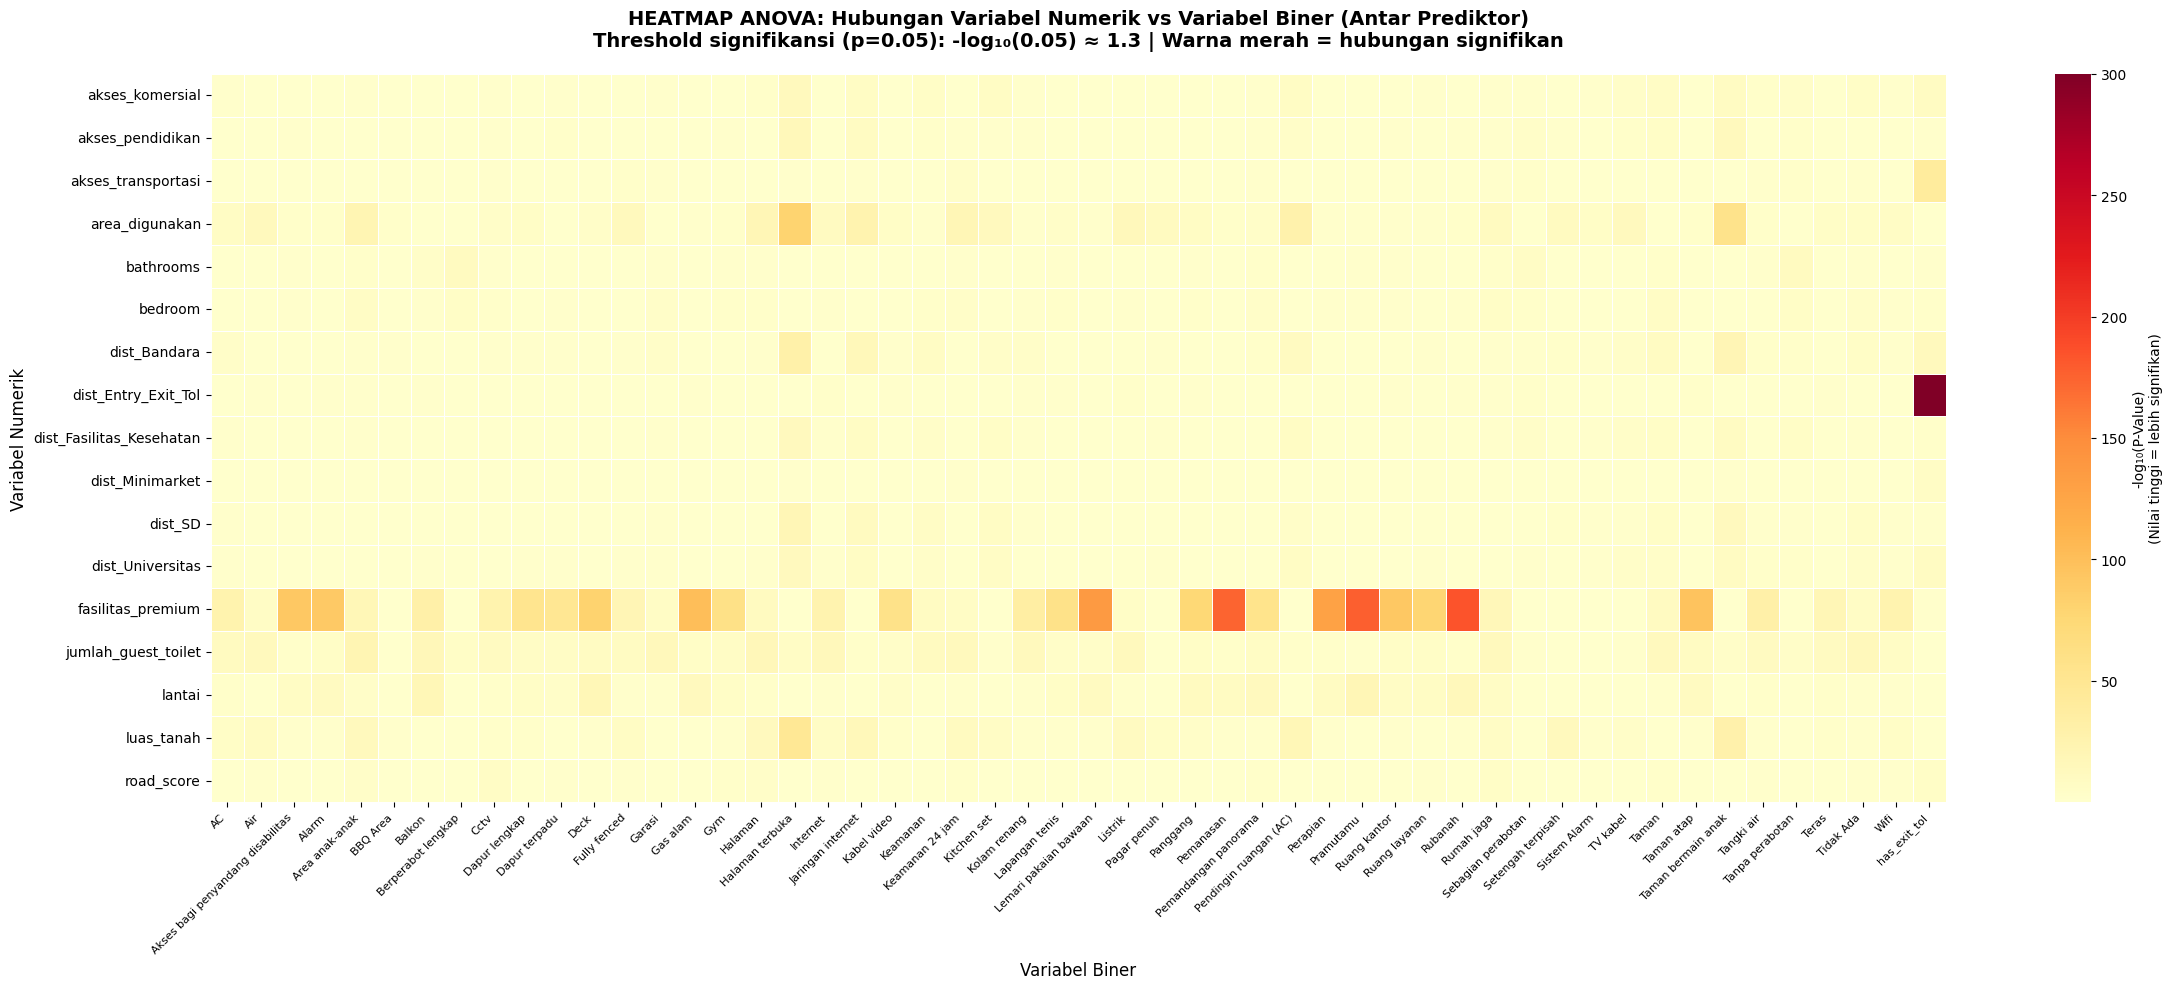

✅ Heatmap ANOVA disimpan: heatmap_anova_predictor.png


In [27]:
# ============================================================
# HEATMAP 1: ANOVA - Variabel Numerik vs Variabel Biner (Antar Prediktor)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Buat pivot table untuk heatmap ANOVA (P-Value)
# Menggunakan -log10(p-value) agar nilai signifikan lebih terlihat
anova_pivot_pval = anova_predictor_df.pivot_table(
    index='Var_Numerik', 
    columns='Var_Biner', 
    values='P-Value',
    aggfunc='first'
)

# Transform ke -log10(p-value) untuk visualisasi lebih baik
# Nilai tinggi = lebih signifikan
anova_pivot_log = -np.log10(anova_pivot_pval + 1e-300)  # tambah epsilon untuk menghindari log(0)

# Buat heatmap
fig, ax = plt.subplots(figsize=(24, 10))
sns.heatmap(
    anova_pivot_log, 
    cmap='YlOrRd',  # Kuning ke Merah (merah = lebih signifikan)
    annot=False,  # Terlalu banyak sel untuk annotate
    fmt='.1f',
    cbar_kws={'label': '-log₁₀(P-Value)\n(Nilai tinggi = lebih signifikan)'},
    linewidths=0.5,
    ax=ax
)

# Tambahkan garis threshold signifikansi
# -log10(0.05) ≈ 1.3
ax.set_title('HEATMAP ANOVA: Hubungan Variabel Numerik vs Variabel Biner (Antar Prediktor)\n' + 
             'Threshold signifikansi (p=0.05): -log₁₀(0.05) ≈ 1.3 | Warna merah = hubungan signifikan',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Variabel Biner', fontsize=12)
ax.set_ylabel('Variabel Numerik', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('/mnt/extended-home/ismaprasetiyadi/skripsi/data/heatmap_anova_predictor.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap ANOVA disimpan: heatmap_anova_predictor.png")

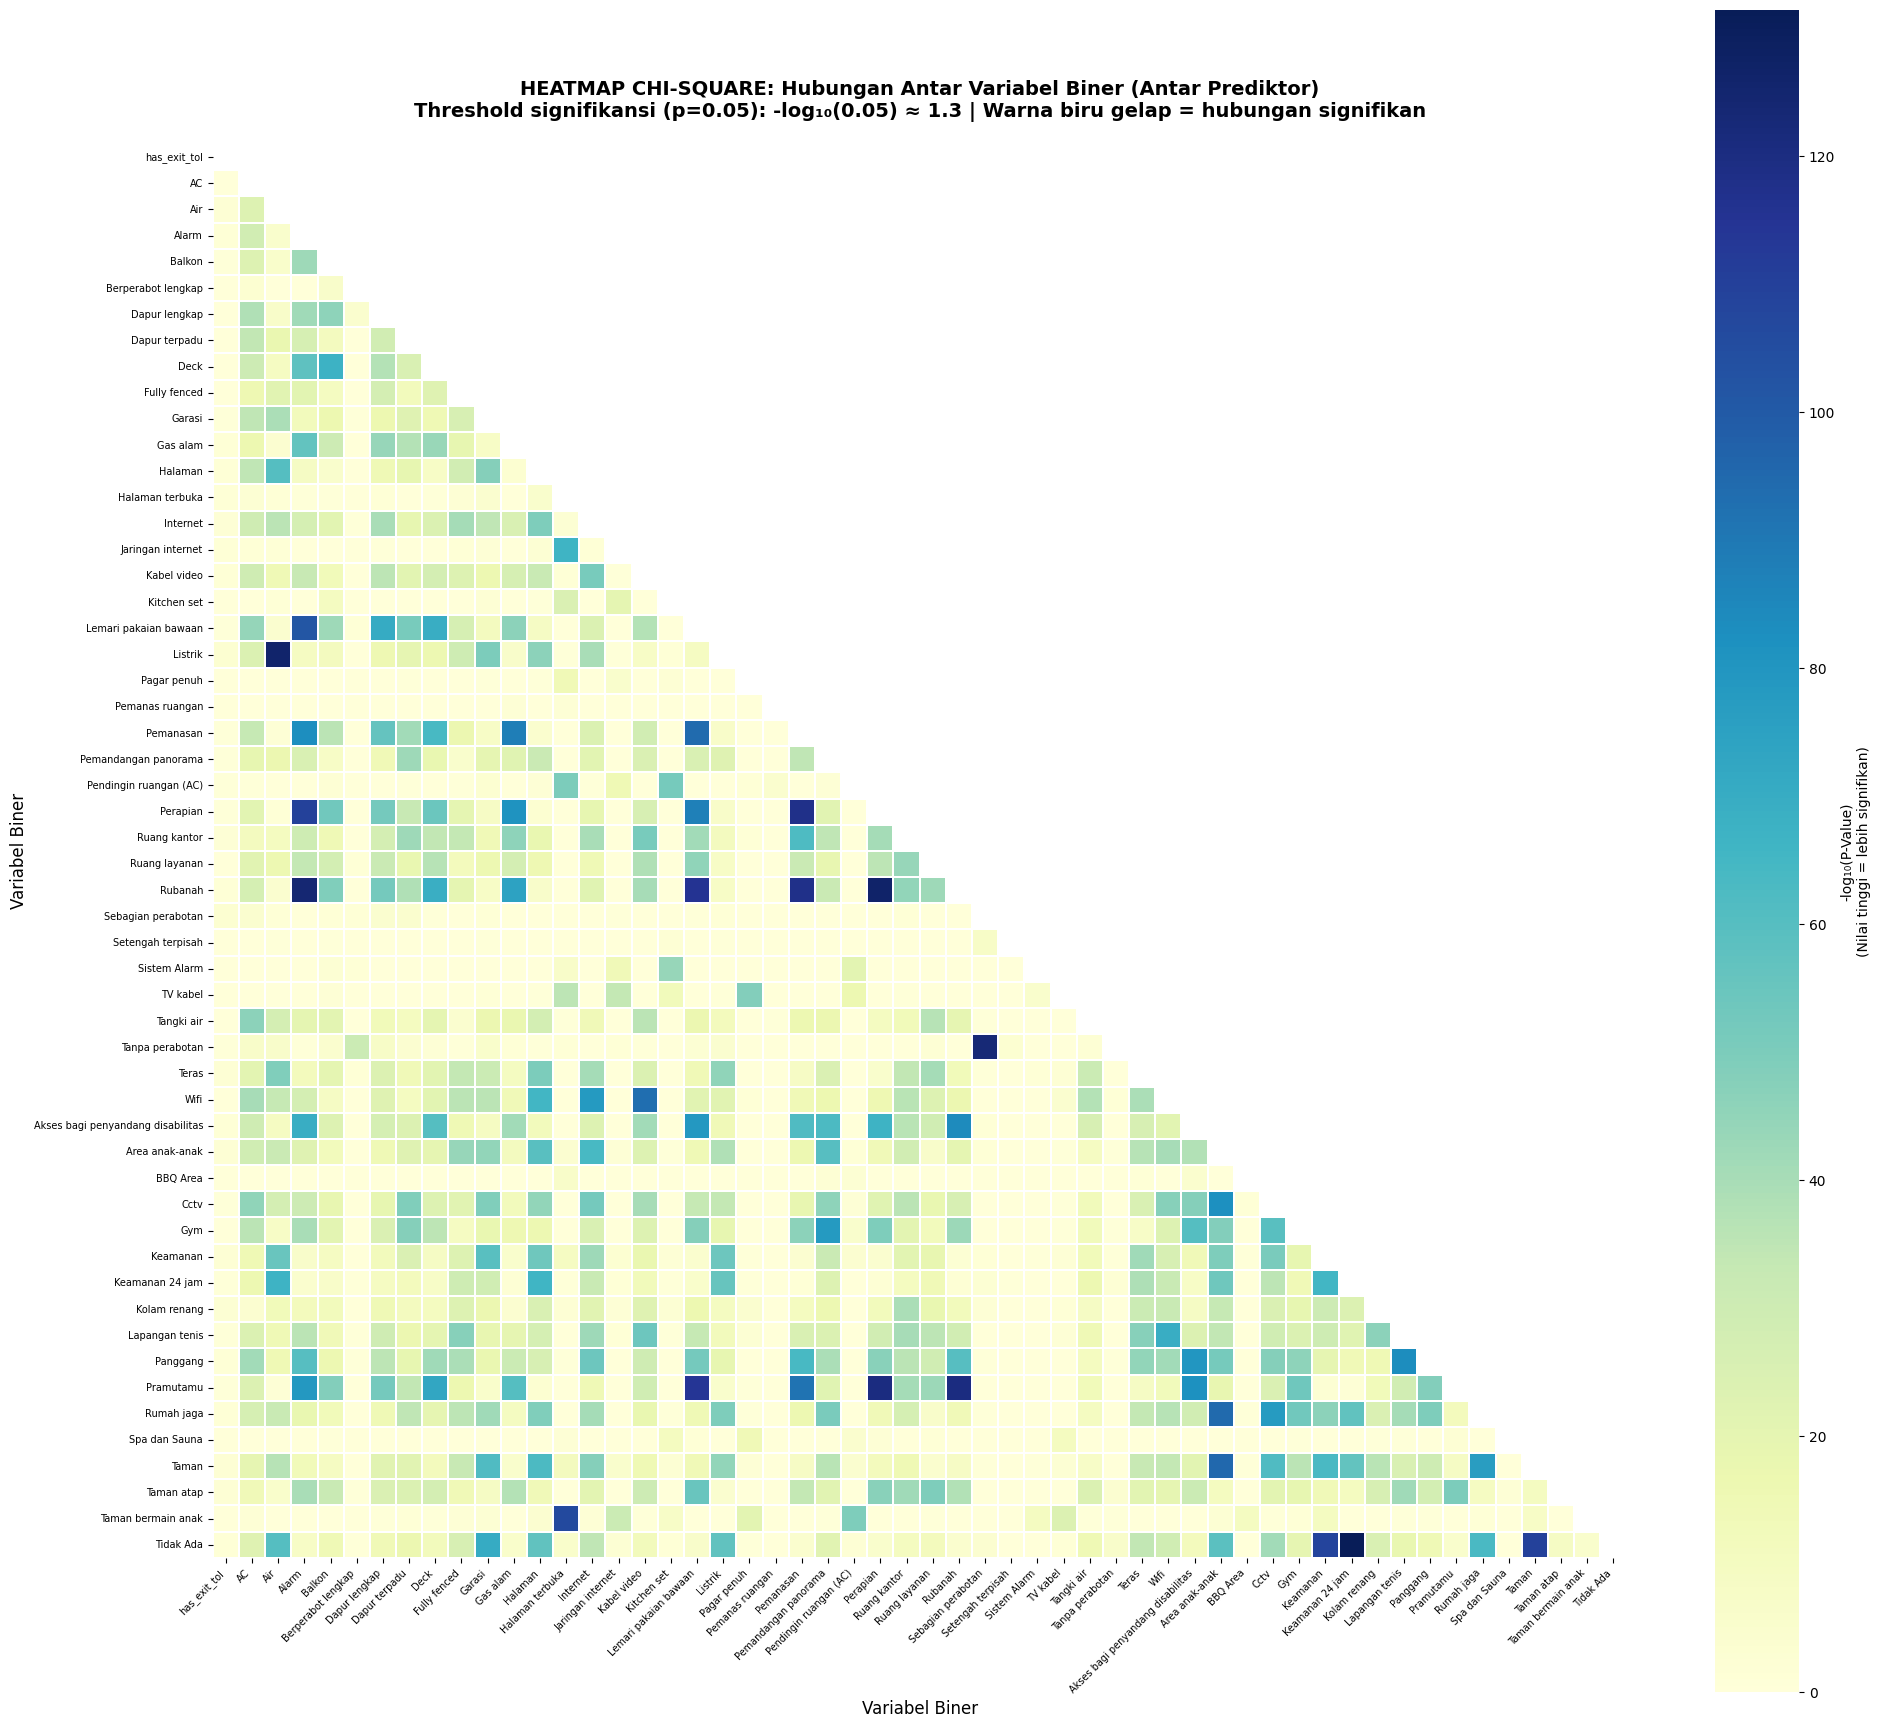

✅ Heatmap Chi-Square disimpan: heatmap_chi_square_predictor.png


In [28]:
# ============================================================
# HEATMAP 2: CHI-SQUARE - Variabel Biner vs Variabel Biner (Antar Prediktor)
# ============================================================

# Buat matrix untuk heatmap Chi-Square
# Karena ini kombinasi pasangan, perlu dibuat matrix simetris
chi2_matrix_pval = pd.DataFrame(
    index=binary_cols,
    columns=binary_cols,
    dtype=float
)

# Isi diagonal dengan 0 (variabel dengan dirinya sendiri)
for col in binary_cols:
    chi2_matrix_pval.loc[col, col] = 1.0  # p-value = 1 untuk diri sendiri

# Isi nilai dari hasil chi-square
for _, row in chi2_predictor_df.iterrows():
    var1, var2 = row['Var_1'], row['Var_2']
    pval = row['P-Value']
    chi2_matrix_pval.loc[var1, var2] = pval
    chi2_matrix_pval.loc[var2, var1] = pval  # Simetris

# Transform ke -log10(p-value)
chi2_matrix_log = -np.log10(chi2_matrix_pval.astype(float) + 1e-300)

# Buat heatmap
fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(chi2_matrix_log, dtype=bool))  # Mask upper triangle

sns.heatmap(
    chi2_matrix_log,
    mask=mask,  # Hanya tampilkan lower triangle
    cmap='YlGnBu',  # Kuning ke Biru
    annot=False,
    cbar_kws={'label': '-log₁₀(P-Value)\n(Nilai tinggi = lebih signifikan)'},
    linewidths=0.3,
    square=True,
    ax=ax
)

ax.set_title('HEATMAP CHI-SQUARE: Hubungan Antar Variabel Biner (Antar Prediktor)\n' +
             'Threshold signifikansi (p=0.05): -log₁₀(0.05) ≈ 1.3 | Warna biru gelap = hubungan signifikan',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Variabel Biner', fontsize=12)
ax.set_ylabel('Variabel Biner', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('/mnt/extended-home/ismaprasetiyadi/skripsi/data/heatmap_chi_square_predictor.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap Chi-Square disimpan: heatmap_chi_square_predictor.png")

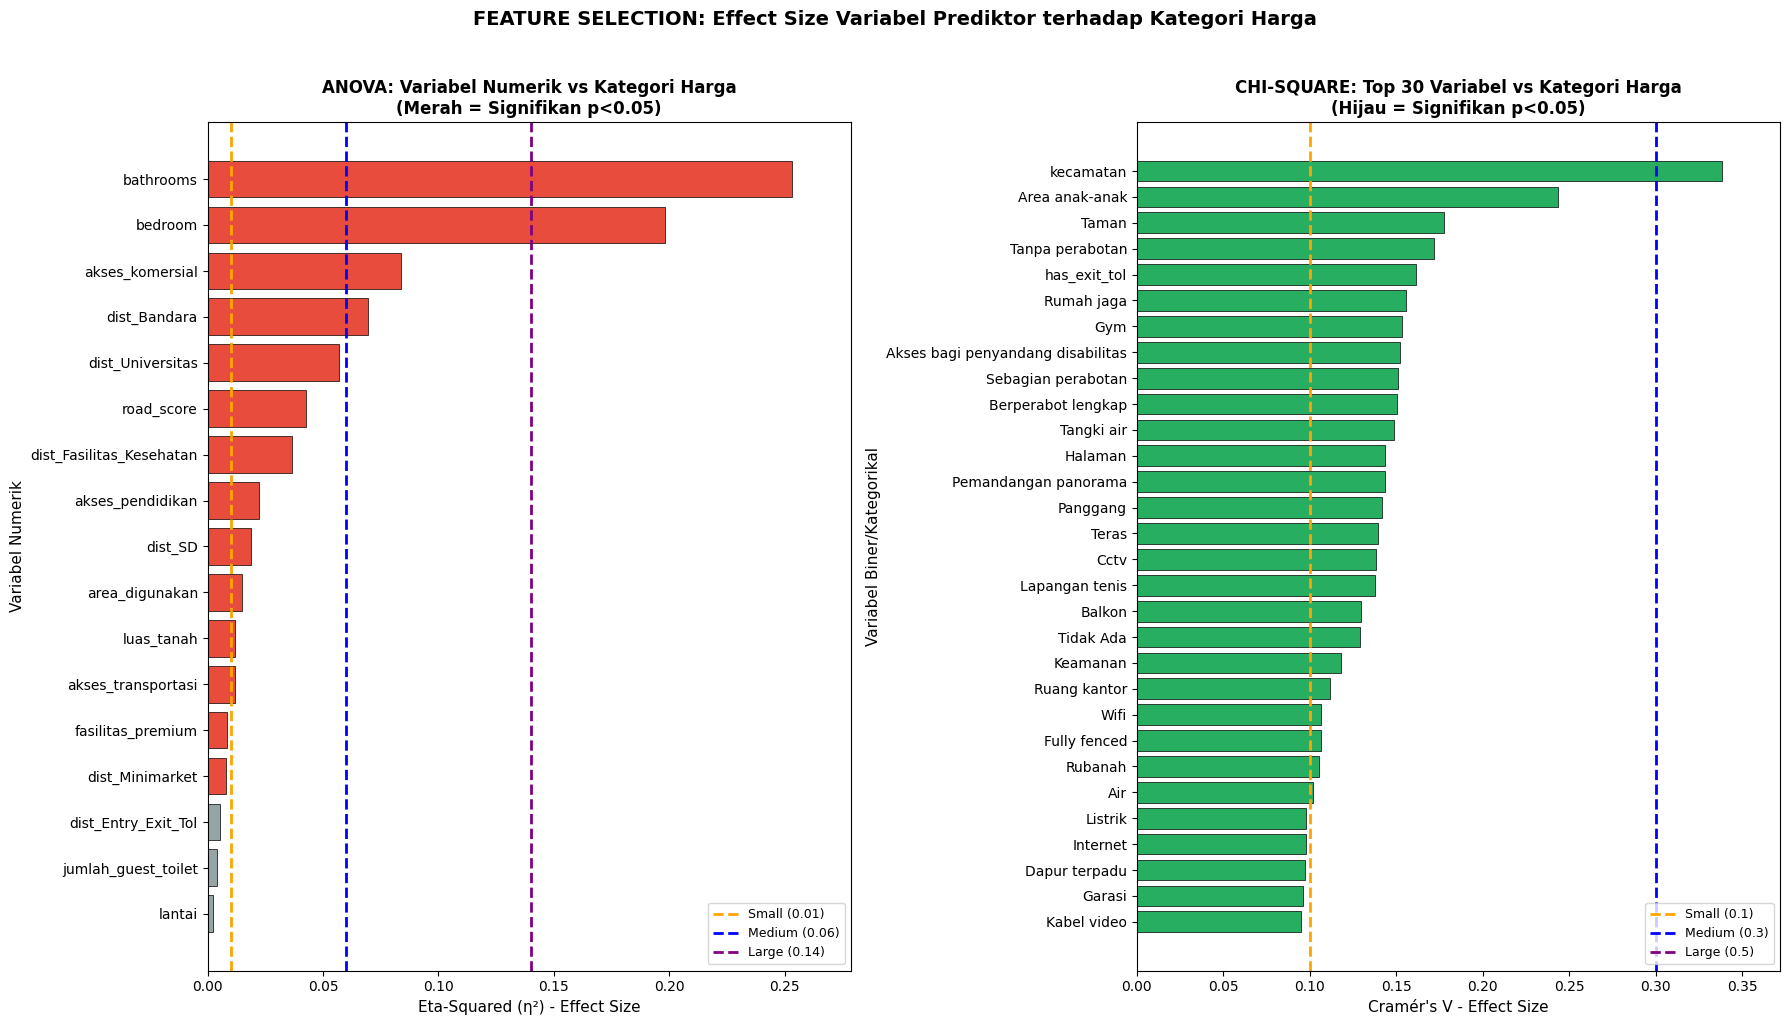

✅ Heatmap Feature vs Target disimpan: heatmap_feature_vs_target.png


In [29]:
# ============================================================
# HEATMAP 3: ANOVA & CHI-SQUARE vs TARGET (Kategori Harga)
# ============================================================
# Heatmap untuk hasil feature selection terhadap variabel target

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# --- ANOVA: Variabel Numerik vs Kategori Harga ---
ax1 = axes[0]

# Siapkan data
anova_heat_data = anova_df.set_index('Variabel')[['Eta-Squared', 'P-Value']].copy()
anova_heat_data['-log10(P)'] = -np.log10(anova_heat_data['P-Value'] + 1e-300)
anova_heat_data = anova_heat_data.sort_values('Eta-Squared', ascending=True)

# Buat heatmap untuk Effect Size (Eta-Squared)
colors_anova = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in anova_heat_data['P-Value']]
bars1 = ax1.barh(anova_heat_data.index, anova_heat_data['Eta-Squared'], color=colors_anova, edgecolor='black', linewidth=0.5)

# Tambah threshold lines
ax1.axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='Small (0.01)')
ax1.axvline(x=0.06, color='blue', linestyle='--', linewidth=2, label='Medium (0.06)')
ax1.axvline(x=0.14, color='purple', linestyle='--', linewidth=2, label='Large (0.14)')

ax1.set_xlabel('Eta-Squared (η²) - Effect Size', fontsize=11)
ax1.set_ylabel('Variabel Numerik', fontsize=11)
ax1.set_title('ANOVA: Variabel Numerik vs Kategori Harga\n(Merah = Signifikan p<0.05)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim(0, max(anova_heat_data['Eta-Squared']) * 1.1)

# --- CHI-SQUARE: Variabel Biner/Kategorikal vs Kategori Harga ---
ax2 = axes[1]

# Siapkan data
chi2_heat_data = chi2_df.set_index('Variabel')[["Cramér's V", 'P-Value']].copy()
chi2_heat_data['-log10(P)'] = -np.log10(chi2_heat_data['P-Value'] + 1e-300)
chi2_heat_data = chi2_heat_data.sort_values("Cramér's V", ascending=True)

# Ambil top 30 untuk visualisasi
chi2_heat_top = chi2_heat_data.nlargest(30, "Cramér's V").sort_values("Cramér's V", ascending=True)

colors_chi2 = ['#27ae60' if p < 0.05 else '#95a5a6' for p in chi2_heat_top['P-Value']]
bars2 = ax2.barh(chi2_heat_top.index, chi2_heat_top["Cramér's V"], color=colors_chi2, edgecolor='black', linewidth=0.5)

# Tambah threshold lines
ax2.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='Small (0.1)')
ax2.axvline(x=0.3, color='blue', linestyle='--', linewidth=2, label='Medium (0.3)')
ax2.axvline(x=0.5, color='purple', linestyle='--', linewidth=2, label='Large (0.5)')

ax2.set_xlabel("Cramér's V - Effect Size", fontsize=11)
ax2.set_ylabel('Variabel Biner/Kategorikal', fontsize=11)
ax2.set_title("CHI-SQUARE: Top 30 Variabel vs Kategori Harga\n(Hijau = Signifikan p<0.05)", fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.set_xlim(0, max(chi2_heat_top["Cramér's V"]) * 1.1)

plt.suptitle('FEATURE SELECTION: Effect Size Variabel Prediktor terhadap Kategori Harga', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/extended-home/ismaprasetiyadi/skripsi/data/heatmap_feature_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap Feature vs Target disimpan: heatmap_feature_vs_target.png")

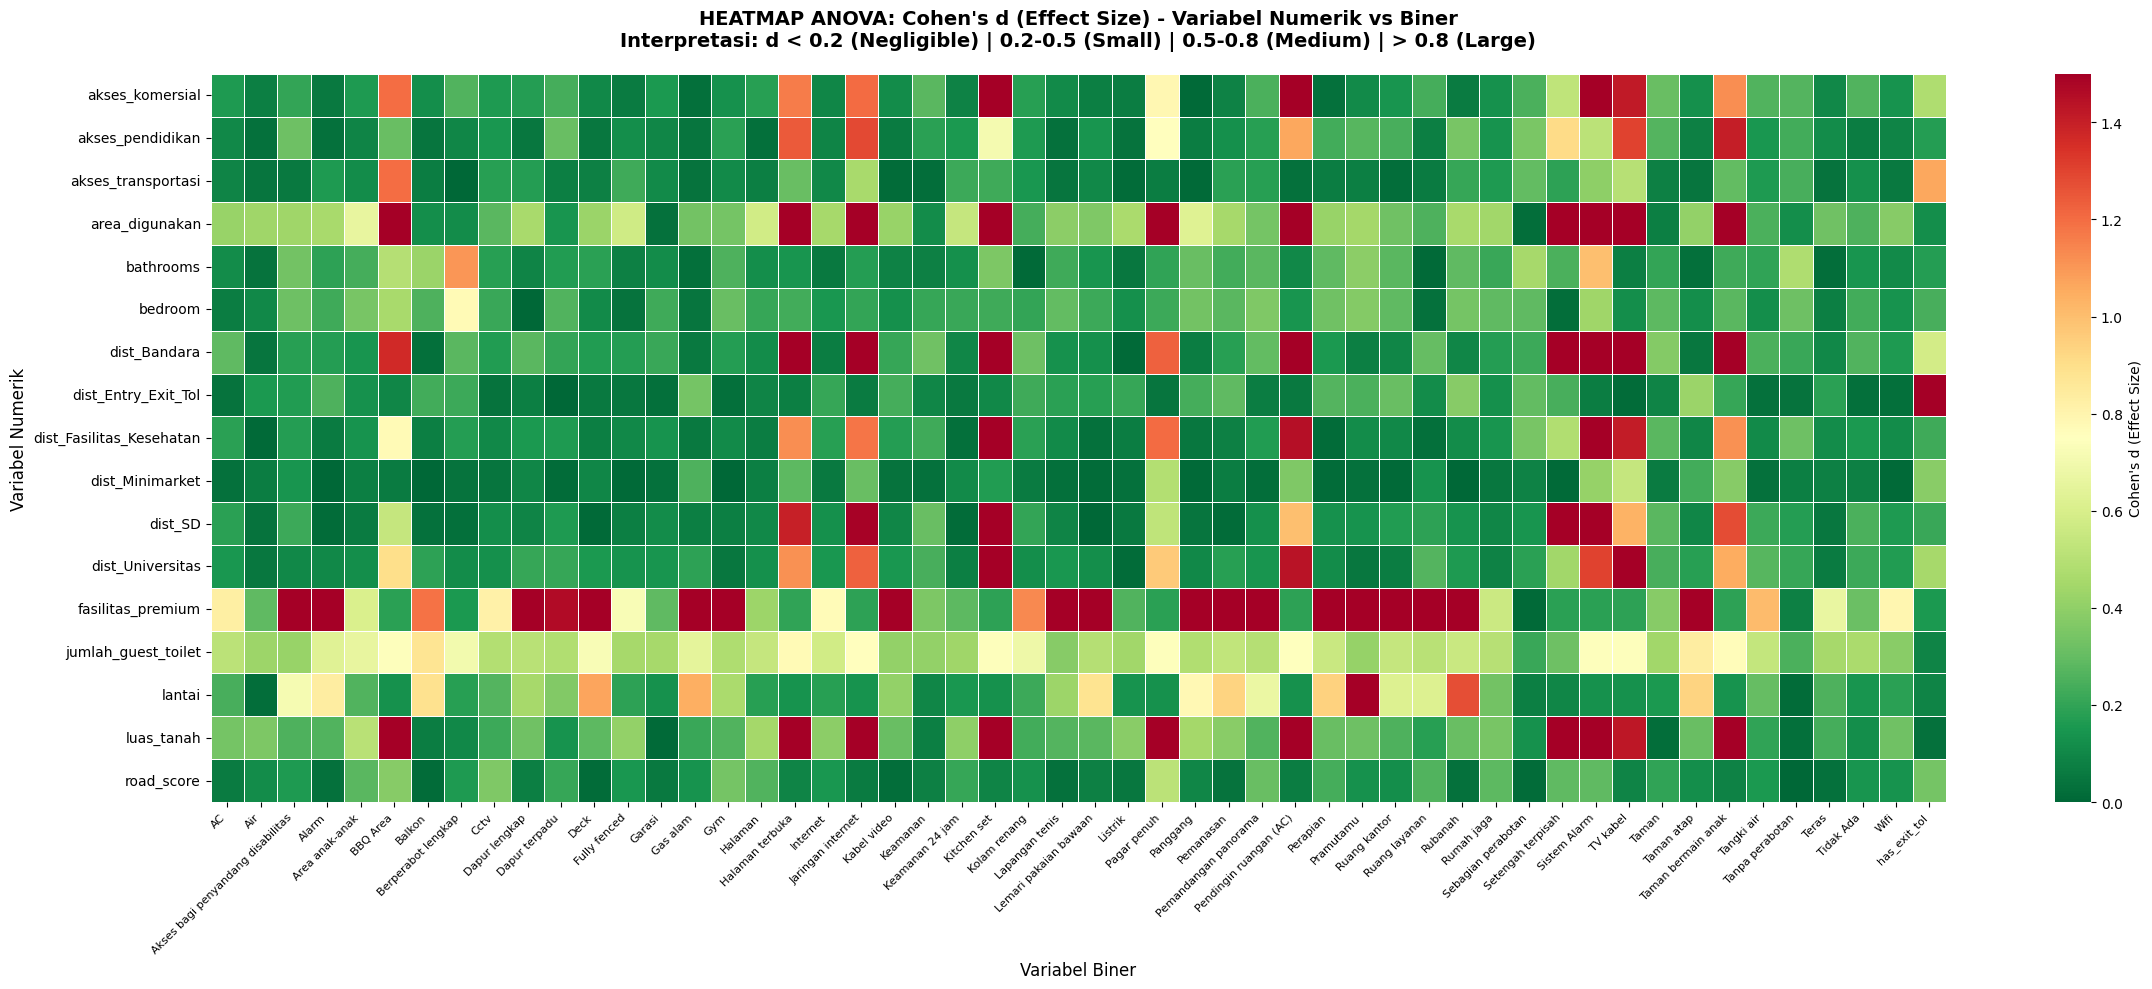

✅ Heatmap Cohen's d disimpan: heatmap_anova_cohens_d.png


In [30]:
# ============================================================
# HEATMAP 4: ANOVA Effect Size (Cohen's d) - Antar Prediktor
# ============================================================

# Buat pivot table untuk heatmap Cohen's d
anova_pivot_cohens = anova_predictor_df.pivot_table(
    index='Var_Numerik', 
    columns='Var_Biner', 
    values="Cohen's d",
    aggfunc='first'
)

fig, ax = plt.subplots(figsize=(24, 10))
sns.heatmap(
    anova_pivot_cohens, 
    cmap='RdYlGn_r',  # Merah = effect besar, Hijau = effect kecil
    annot=False,
    cbar_kws={'label': "Cohen's d (Effect Size)"},
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1.5  # Cap at 1.5 for better visualization
)

ax.set_title("HEATMAP ANOVA: Cohen's d (Effect Size) - Variabel Numerik vs Biner\n" +
             "Interpretasi: d < 0.2 (Negligible) | 0.2-0.5 (Small) | 0.5-0.8 (Medium) | > 0.8 (Large)",
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Variabel Biner', fontsize=12)
ax.set_ylabel('Variabel Numerik', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('/mnt/extended-home/ismaprasetiyadi/skripsi/data/heatmap_anova_cohens_d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap Cohen's d disimpan: heatmap_anova_cohens_d.png")

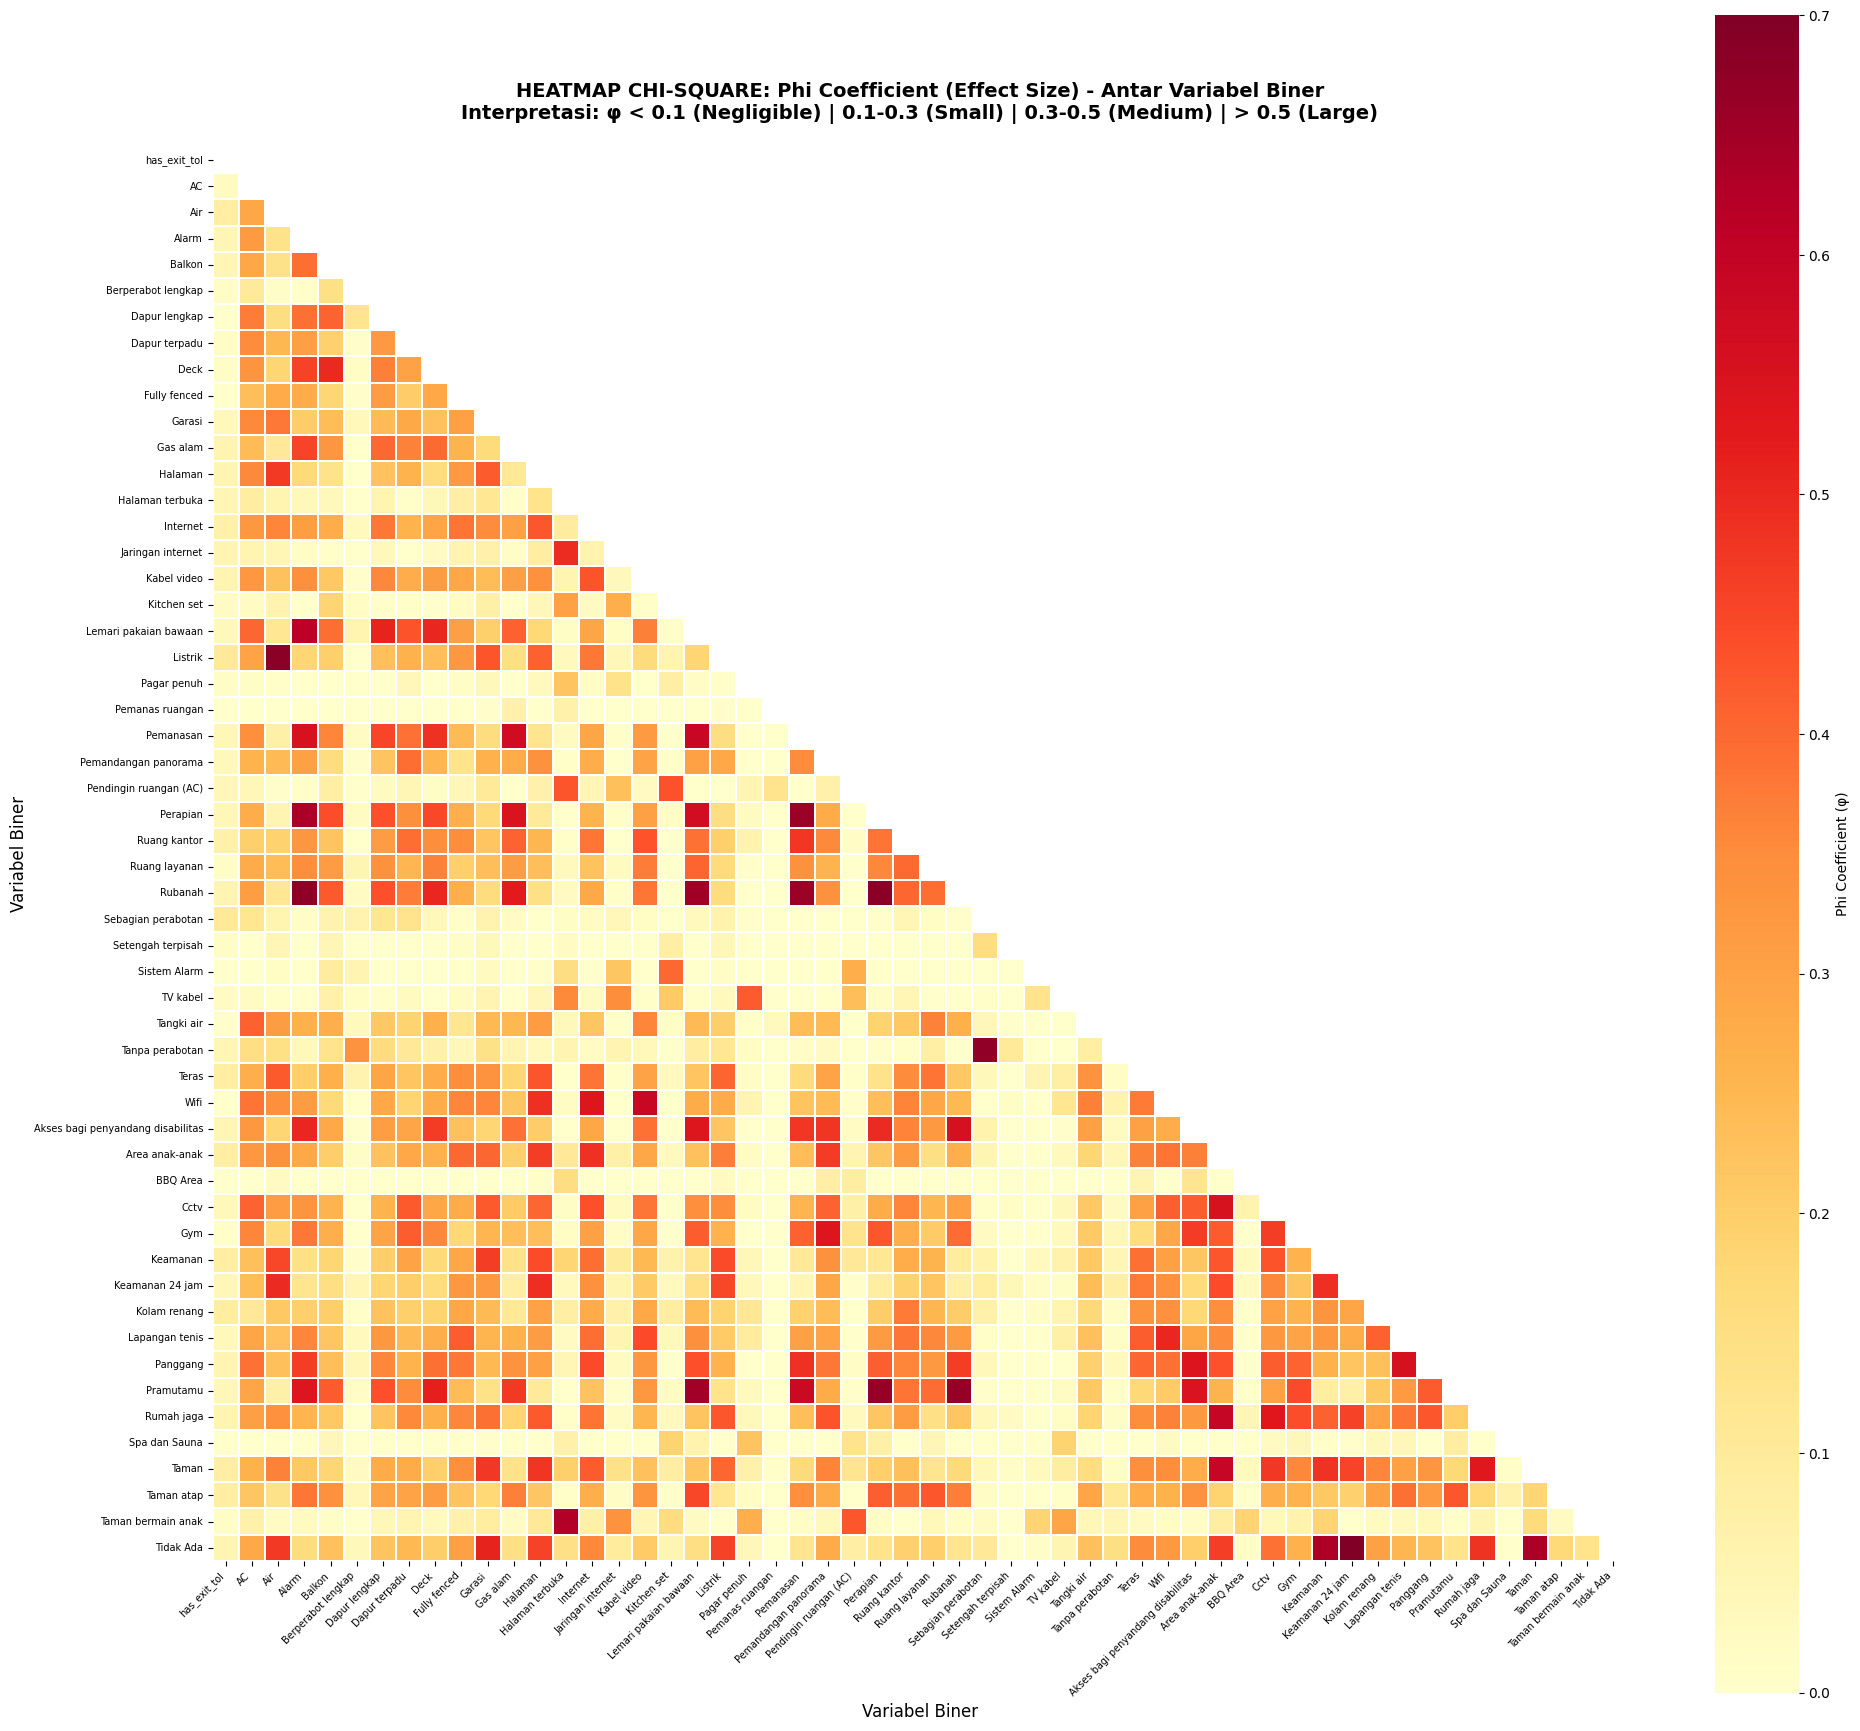

✅ Heatmap Phi Coefficient disimpan: heatmap_chi_square_phi.png


In [31]:
# ============================================================
# HEATMAP 5: CHI-SQUARE Phi Coefficient - Antar Prediktor Biner
# ============================================================

# Buat matrix untuk Phi coefficient
chi2_matrix_phi = pd.DataFrame(
    index=binary_cols,
    columns=binary_cols,
    dtype=float
)

# Isi diagonal dengan 1 (variabel dengan dirinya sendiri sempurna)
for col in binary_cols:
    chi2_matrix_phi.loc[col, col] = 0.0

# Isi nilai dari hasil chi-square
for _, row in chi2_predictor_df.iterrows():
    var1, var2 = row['Var_1'], row['Var_2']
    phi = row['Phi']
    chi2_matrix_phi.loc[var1, var2] = phi
    chi2_matrix_phi.loc[var2, var1] = phi  # Simetris

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(chi2_matrix_phi.astype(float), dtype=bool))

sns.heatmap(
    chi2_matrix_phi.astype(float),
    mask=mask,
    cmap='YlOrRd',  # Kuning ke Merah
    annot=False,
    cbar_kws={'label': 'Phi Coefficient (φ)'},
    linewidths=0.3,
    square=True,
    ax=ax,
    vmin=0,
    vmax=0.7
)

ax.set_title("HEATMAP CHI-SQUARE: Phi Coefficient (Effect Size) - Antar Variabel Biner\n" +
             "Interpretasi: φ < 0.1 (Negligible) | 0.1-0.3 (Small) | 0.3-0.5 (Medium) | > 0.5 (Large)",
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Variabel Biner', fontsize=12)
ax.set_ylabel('Variabel Biner', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('/mnt/extended-home/ismaprasetiyadi/skripsi/data/heatmap_chi_square_phi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap Phi Coefficient disimpan: heatmap_chi_square_phi.png")

In [32]:
# ============================================================
# RINGKASAN SEMUA HEATMAP YANG TELAH DIBUAT
# ============================================================

print("="*80)
print("📊 RINGKASAN VISUALISASI HEATMAP YANG TELAH DIBUAT")
print("="*80)

summary_heatmaps = """
┌────────────────────────────────────────────────────────────────────────────────┐
│                         DAFTAR HEATMAP YANG TERSIMPAN                          │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📁 Lokasi: /mnt/extended-home/ismaprasetiyadi/skripsi/data/                   │
│                                                                                │
│  ┌──────────────────────────────────────────────────────────────────────────┐  │
│  │ 1. heatmap_anova_predictor.png                                           │  │
│  │    ANOVA: -log₁₀(P-Value) Variabel Numerik vs Biner                      │  │
│  │    Colormap: YlOrRd (Merah = Signifikan)                                 │  │
│  ├──────────────────────────────────────────────────────────────────────────┤  │
│  │ 2. heatmap_chi_square_predictor.png                                      │  │
│  │    Chi-Square: -log₁₀(P-Value) Antar Variabel Biner                      │  │
│  │    Colormap: YlGnBu (Biru Gelap = Signifikan)                            │  │
│  ├──────────────────────────────────────────────────────────────────────────┤  │
│  │ 3. heatmap_feature_vs_target.png                                         │  │
│  │    Bar Chart Effect Size: Prediktor vs Kategori Harga                    │  │
│  │    ANOVA (Eta²) & Chi-Square (Cramér's V)                                │  │
│  ├──────────────────────────────────────────────────────────────────────────┤  │
│  │ 4. heatmap_anova_cohens_d.png                                            │  │
│  │    ANOVA: Cohen's d (Effect Size) Numerik vs Biner                       │  │
│  │    Colormap: RdYlGn_r (Merah = Effect Besar)                             │  │
│  ├──────────────────────────────────────────────────────────────────────────┤  │
│  │ 5. heatmap_chi_square_phi.png                                            │  │
│  │    Chi-Square: Phi Coefficient Antar Variabel Biner                      │  │
│  │    Colormap: YlOrRd (Merah = Effect Besar)                               │  │
│  └──────────────────────────────────────────────────────────────────────────┘  │
│                                                                                │
├────────────────────────────────────────────────────────────────────────────────┤
│                              INTERPRETASI WARNA                                │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📌 P-Value Heatmaps (-log₁₀ transformation):                                  │
│     • Nilai tinggi (warna gelap) = P-value rendah = SIGNIFIKAN                 │
│     • Threshold: -log₁₀(0.05) ≈ 1.3                                            │
│                                                                                │
│  📌 Effect Size Heatmaps:                                                      │
│     • Cohen's d: < 0.2 (Negligible) | 0.2-0.5 (Small) | 0.5-0.8 (Med) | >0.8  │
│     • Phi (φ): < 0.1 (Negligible) | 0.1-0.3 (Small) | 0.3-0.5 (Med) | >0.5    │
│                                                                                │
└────────────────────────────────────────────────────────────────────────────────┘
"""
print(summary_heatmaps)

📊 RINGKASAN VISUALISASI HEATMAP YANG TELAH DIBUAT

┌────────────────────────────────────────────────────────────────────────────────┐
│                         DAFTAR HEATMAP YANG TERSIMPAN                          │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📁 Lokasi: /mnt/extended-home/ismaprasetiyadi/skripsi/data/                   │
│                                                                                │
│  ┌──────────────────────────────────────────────────────────────────────────┐  │
│  │ 1. heatmap_anova_predictor.png                                           │  │
│  │    ANOVA: -log₁₀(P-Value) Variabel Numerik vs Biner                      │  │
│  │    Colormap: YlOrRd (Merah = Signifikan)                                 │  │
│  ├──────────────────────────────────────────────────────────────────────────┤  │
│  │ 2. heatmap_chi_square_predictor.